In [4]:
import anndata as ad
import scanpy as sc
from matplotlib import rcParams
#import squidpy as sq
#import harmonypy as hm
import pandas as pd
#import scanorama
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import numpy as np

def rotate_points(spatial, theta):
    # Define the rotation matrix
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    
    # Rotate the points
    rotated_points = spatial @ rotation_matrix.T
    
    return rotated_points

# Example usage
# Create a set of points (for example)
spatial = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# Define the rotation angle (in radians)
theta = np.pi / 4  # 45 degrees

# Rotate the points
rotated_spatial = rotate_points(spatial, theta)
print(rotated_spatial)

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


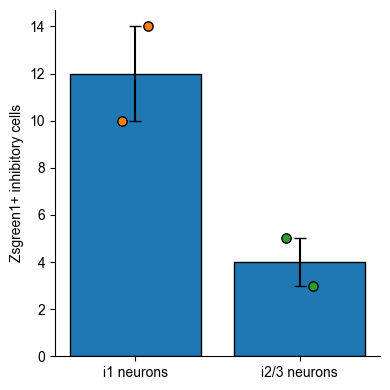

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"
data = {
    "i1 neurons": [10,14],
    "i2/3 neurons": [5,3]
}

labels = list(data.keys())
values = [np.asarray(data[label], dtype=float) for label in labels]

means = np.array([x.mean() for x in values])
sems = np.array([
    x.std(ddof=1) / np.sqrt(len(x))
    if len(x) > 1 else 0
    for x in values
])

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(4, 4))

# Mean bars with SEM
ax.bar(
    x,
    means,
    yerr=sems,
    capsize=4,
    edgecolor="black",
    linewidth=1,
)

# Individual replicate values
offsets = np.array([-0.08, 0.08])

for i, vals in enumerate(values):
    ax.scatter(
        x[i] + offsets[:len(vals)],
        vals,
        s=45,
        edgecolor="black",
        zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Zsgreen1+ inhibitory cells")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("inhib_nuclei_counts.svg", bbox_inches="tight")
plt.savefig("inhib_nuclei_counts.pdf", bbox_inches="tight")
plt.show()

In [7]:
import numpy as np

def rotate_points(spatial, theta):
    # Define the rotation matrix
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    
    # Rotate the points
    rotated_points = spatial @ rotation_matrix.T
    
    return rotated_points

# Example usage
# Create a set of points (for example)
spatial = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# Define the rotation angle (in radians)
theta = np.pi / 4  # 45 degrees

# Rotate the points
rotated_spatial = rotate_points(spatial, theta)
print(rotated_spatial)

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


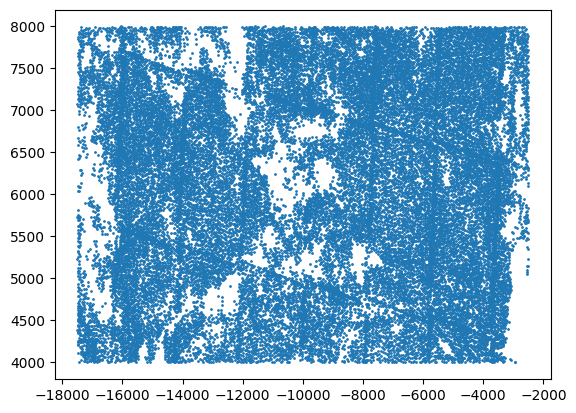

In [8]:
import matplotlib.pyplot as plt

adata_full = sc.read_h5ad('/Users/manjjj/Downloads/adata (12).h5ad')

adata_full.obsm['spatial'] = rotate_points(adata_full.obsm['spatial'], (82/180)*3.14)
adata_full_coor = adata_full.obsm['spatial'][adata_full.obsm['spatial'][:,1] > 4000]
adata_full_coor = adata_full_coor[adata_full_coor[:,1] <8000]
adata_full_coor = adata_full_coor[adata_full_coor[:,0] <-2500]
adata_full_coor = adata_full_coor[adata_full_coor[:,0] >-17500]
plt.scatter(adata_full_coor[:,0],adata_full_coor[:,1], s= 1)

adata_full_coor_set = {tuple(coord) for coord in adata_full_coor}
mask = np.array([tuple(coord) in adata_full_coor_set for coord in adata_full.obsm['spatial']])
adata_full_corr = adata_full[mask]

adata_full_corr.obsm['spatial3d'] = np.zeros([len(adata_full_corr),3])
x = adata_full_corr.obsm['spatial'][:,0]
y = adata_full_corr.obsm['spatial'][:,1]
adata_full_corr.obsm['spatial'][:,0] = (x - np.min(x))
adata_full_corr.obsm['spatial'][:,1] = (y - np.min(y))
adata_full_corr.obsm['spatial3d'][:,0] = (x - np.min(x))
adata_full_corr.obsm['spatial3d'][:,1] = (y - np.min(y))
adata_full_corr.obsm['spatial3d'][:,2] = 0

In [10]:
adata_full_corr.obsm['spatial'][:,1] = np.max(adata_full_corr.obsm['spatial'][:,1]) - adata_full_corr.obsm['spatial'][:,1]

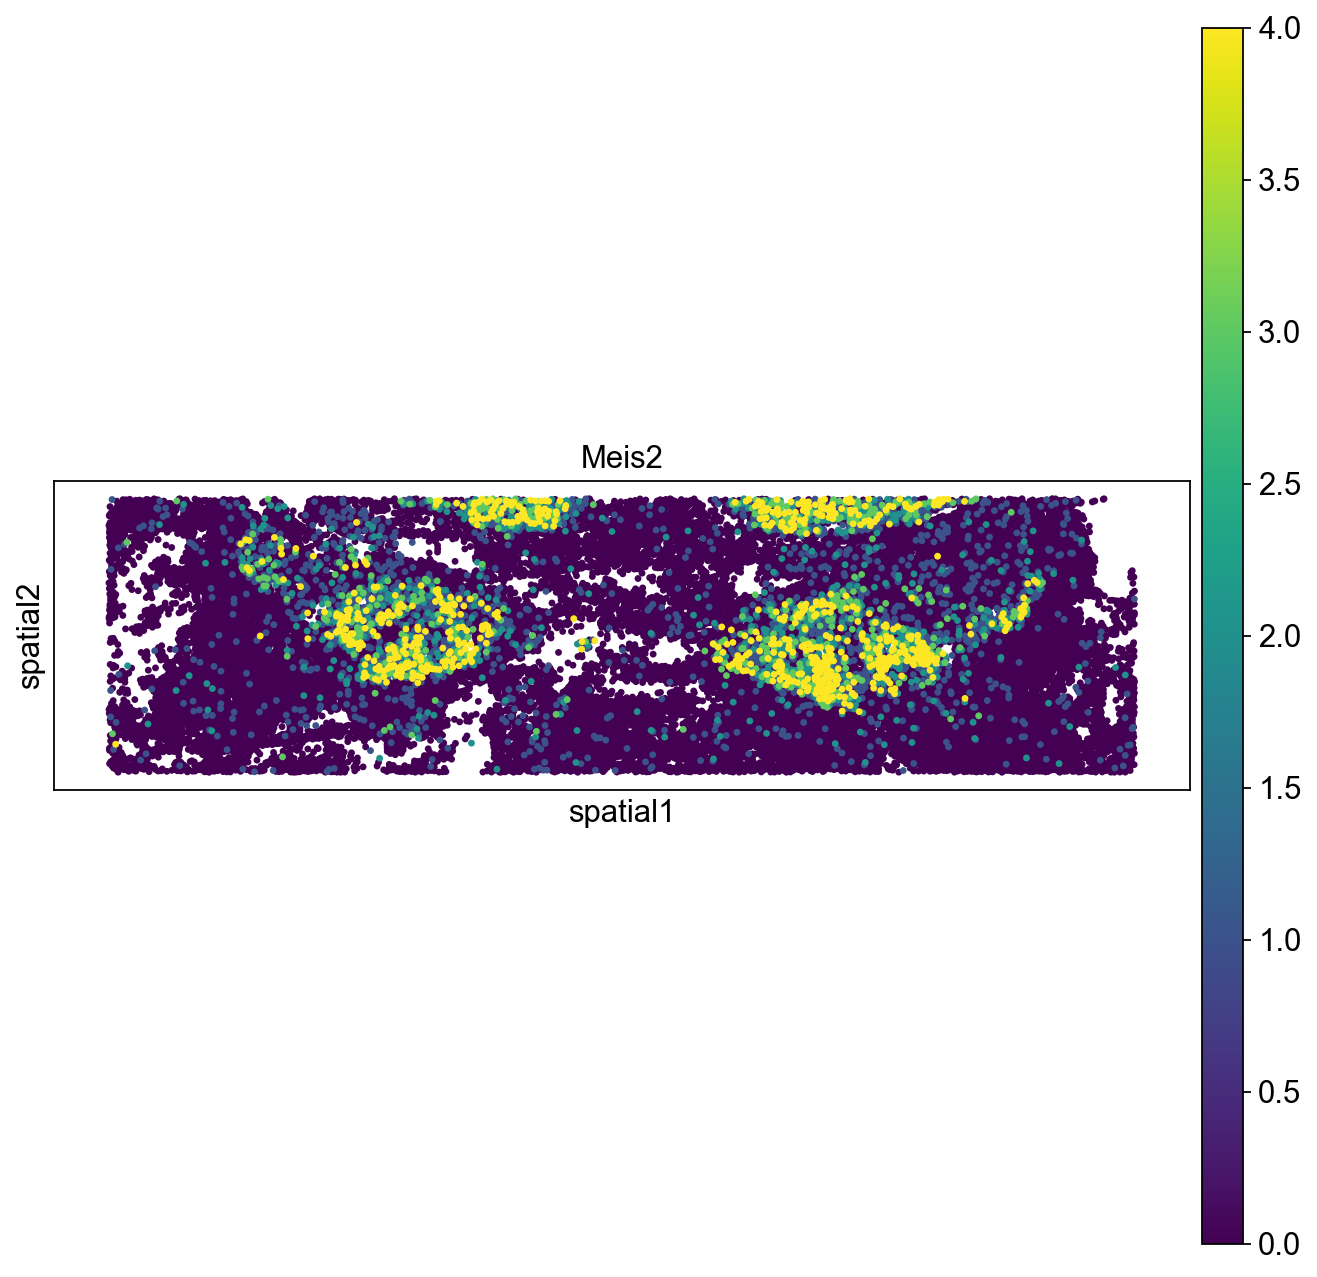

In [9]:
sc.set_figure_params(figsize = (10,10))
sc.pl.spatial(adata_full_corr, color = "Meis2", spot_size = 100, vmax = 4)

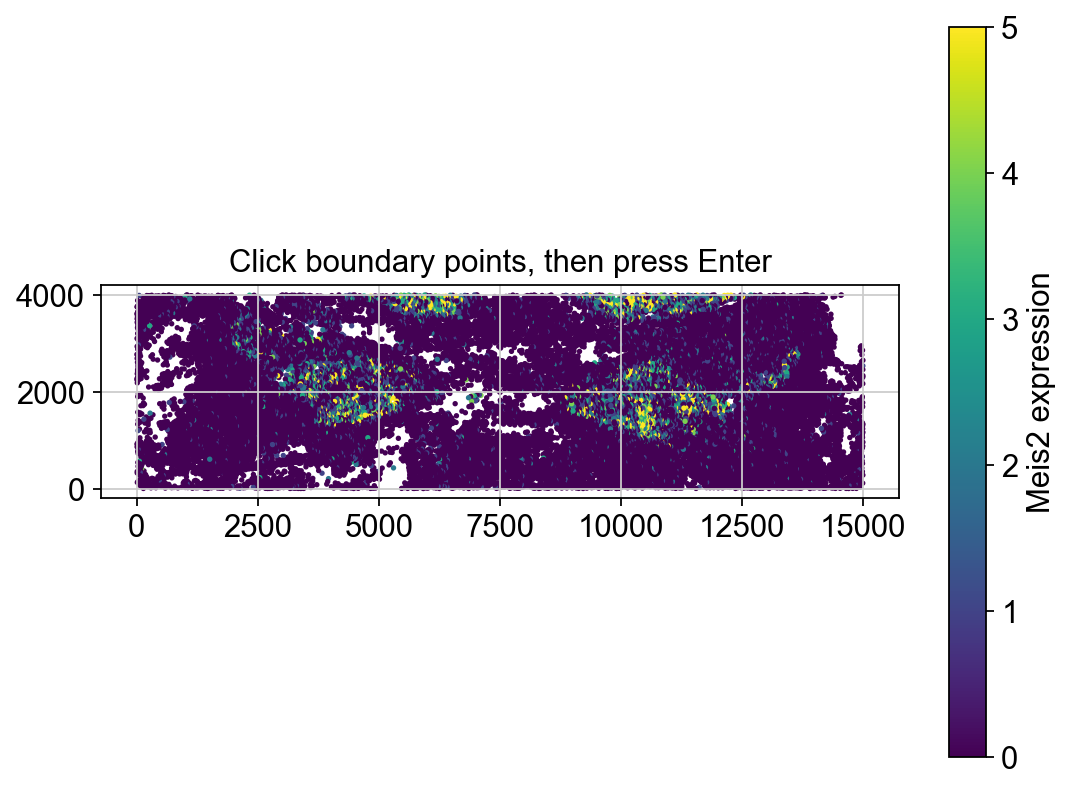

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path

# get expression
meis2 = adata_full_corr[:, "Meis2"].X
if hasattr(meis2, "toarray"):
    meis2 = meis2.toarray()
meis2 = np.asarray(meis2).ravel()

coords = adata_full_corr.obsm["spatial"]

fig, ax = plt.subplots(figsize=(8, 6))

scat = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=meis2,
    s=2,
    cmap="viridis",
    vmax=np.percentile(meis2, 99),
)

plt.colorbar(scat, ax=ax, label="Meis2 expression")
ax.set_aspect("equal")
ax.set_title("Click boundary points, then press Enter")

plt.show()

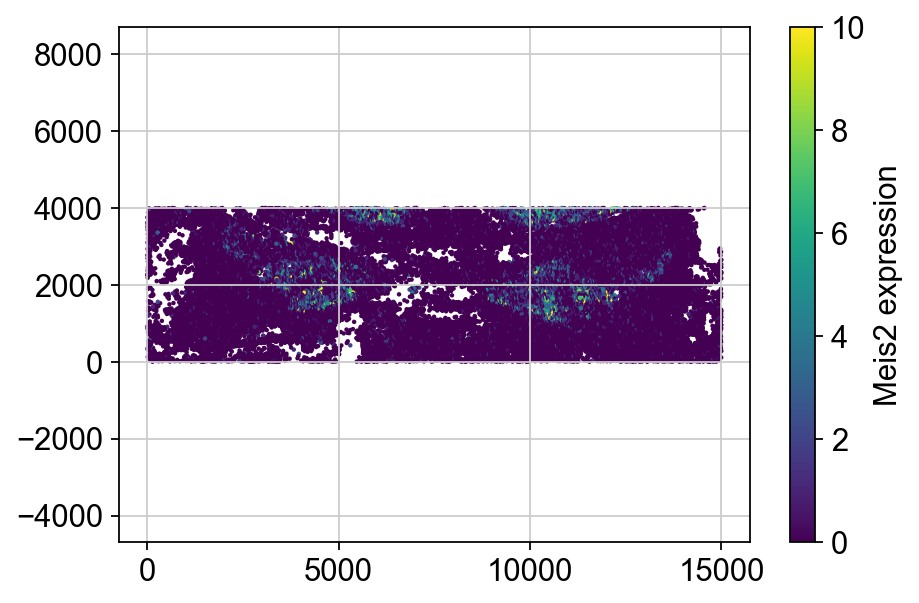

In [16]:
import matplotlib.pyplot as plt
import numpy as np

meis2 = adata_full_corr[:, "Meis2"].X

# handle sparse matrix
if hasattr(meis2, "toarray"):
    meis2 = meis2.toarray()

meis2 = np.asarray(meis2).ravel()

plt.figure(figsize=(6, 4))
plt.scatter(
    adata_full_corr.obsm["spatial"][:, 0],
    adata_full_corr.obsm["spatial"][:, 1],
    c=meis2,
    s=1,
    cmap="viridis",
    vmax = 10
)
plt.colorbar(label="Meis2 expression")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [17]:
adata_full_corr.obsm['spatial'][:,1] = np.max(adata_full_corr.obsm['spatial'][:,1]) - adata_full_corr.obsm['spatial'][:,1]

In [18]:
adata_full_corr

AnnData object with n_obs × n_vars = 32538 × 31
    obs: 'cell_number', 'gfp_mean_intensity', 'gfp_median_intensity', 'gfp_std_intensity', 'gfp_max_intensity', 'gfp_sum_intensity', 'gfp_p90_intensity', 'gfp_p95_intensity', 'gfp_p99_intensity', 'gfp_cv_intensity', 'gfp_top10_mean_intensity', 'gfp_n_pixels', 'gfp_n_pixels_above_300', 'gfp_fraction_pixels_above_300', 'gfp_n_pixels_above_500', 'gfp_fraction_pixels_above_500'
    var: 'genes'
    obsm: 'spatial', 'spatial3d'

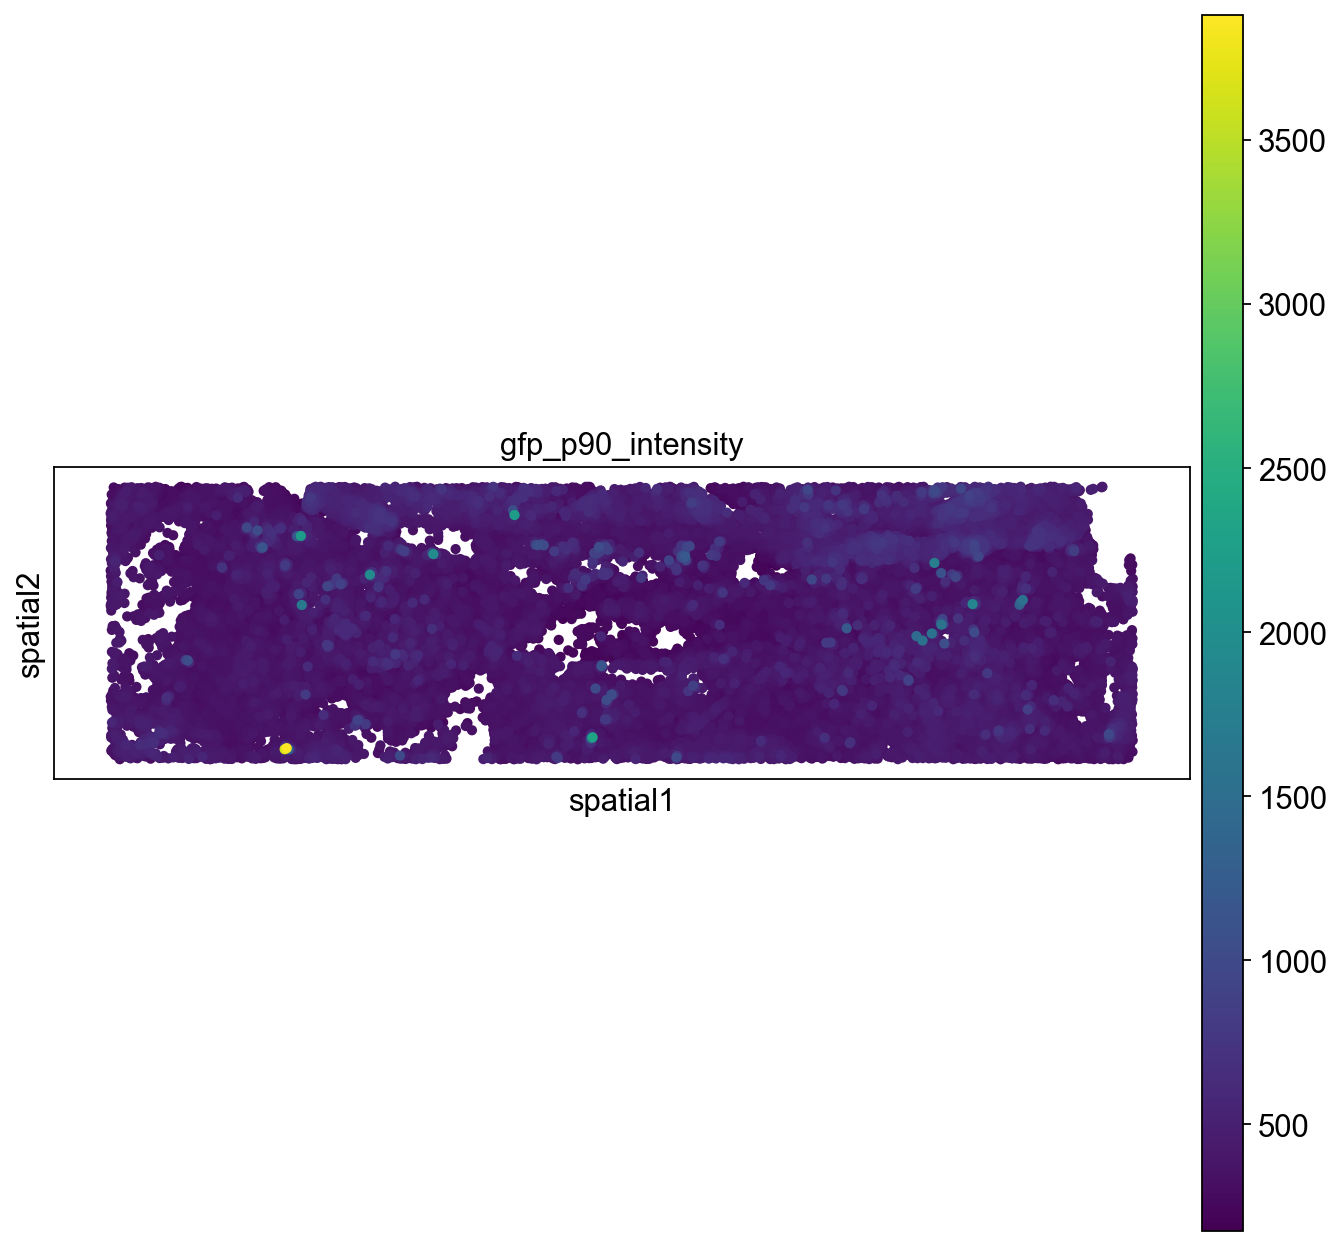

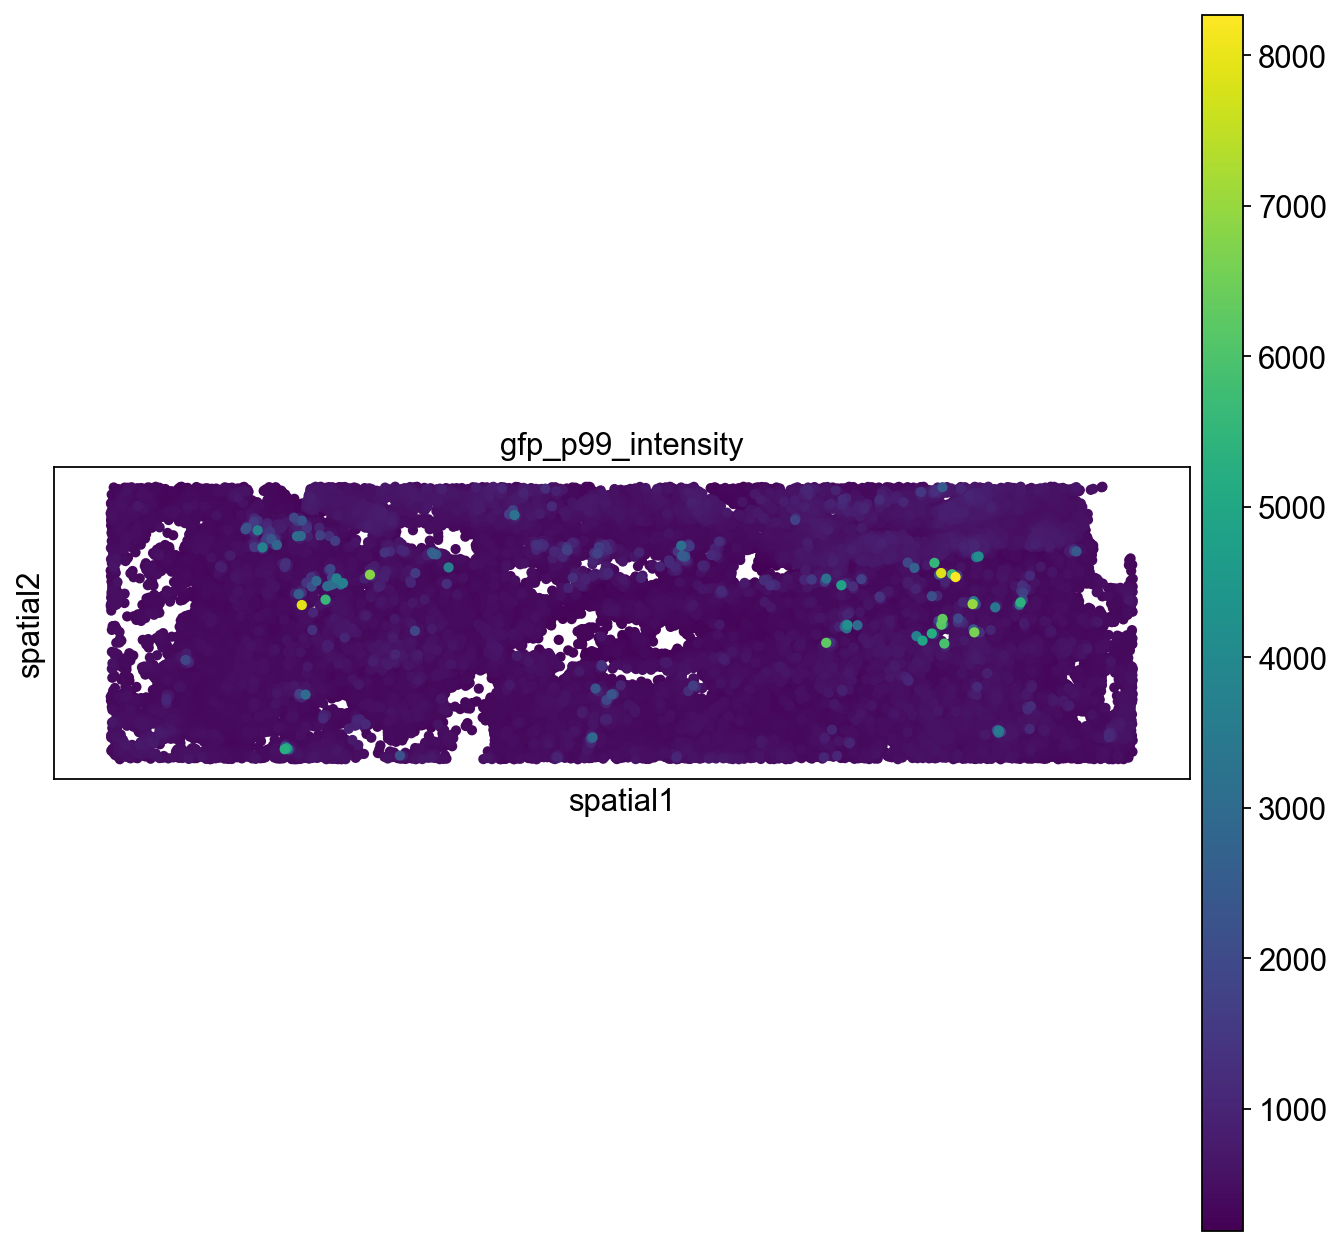

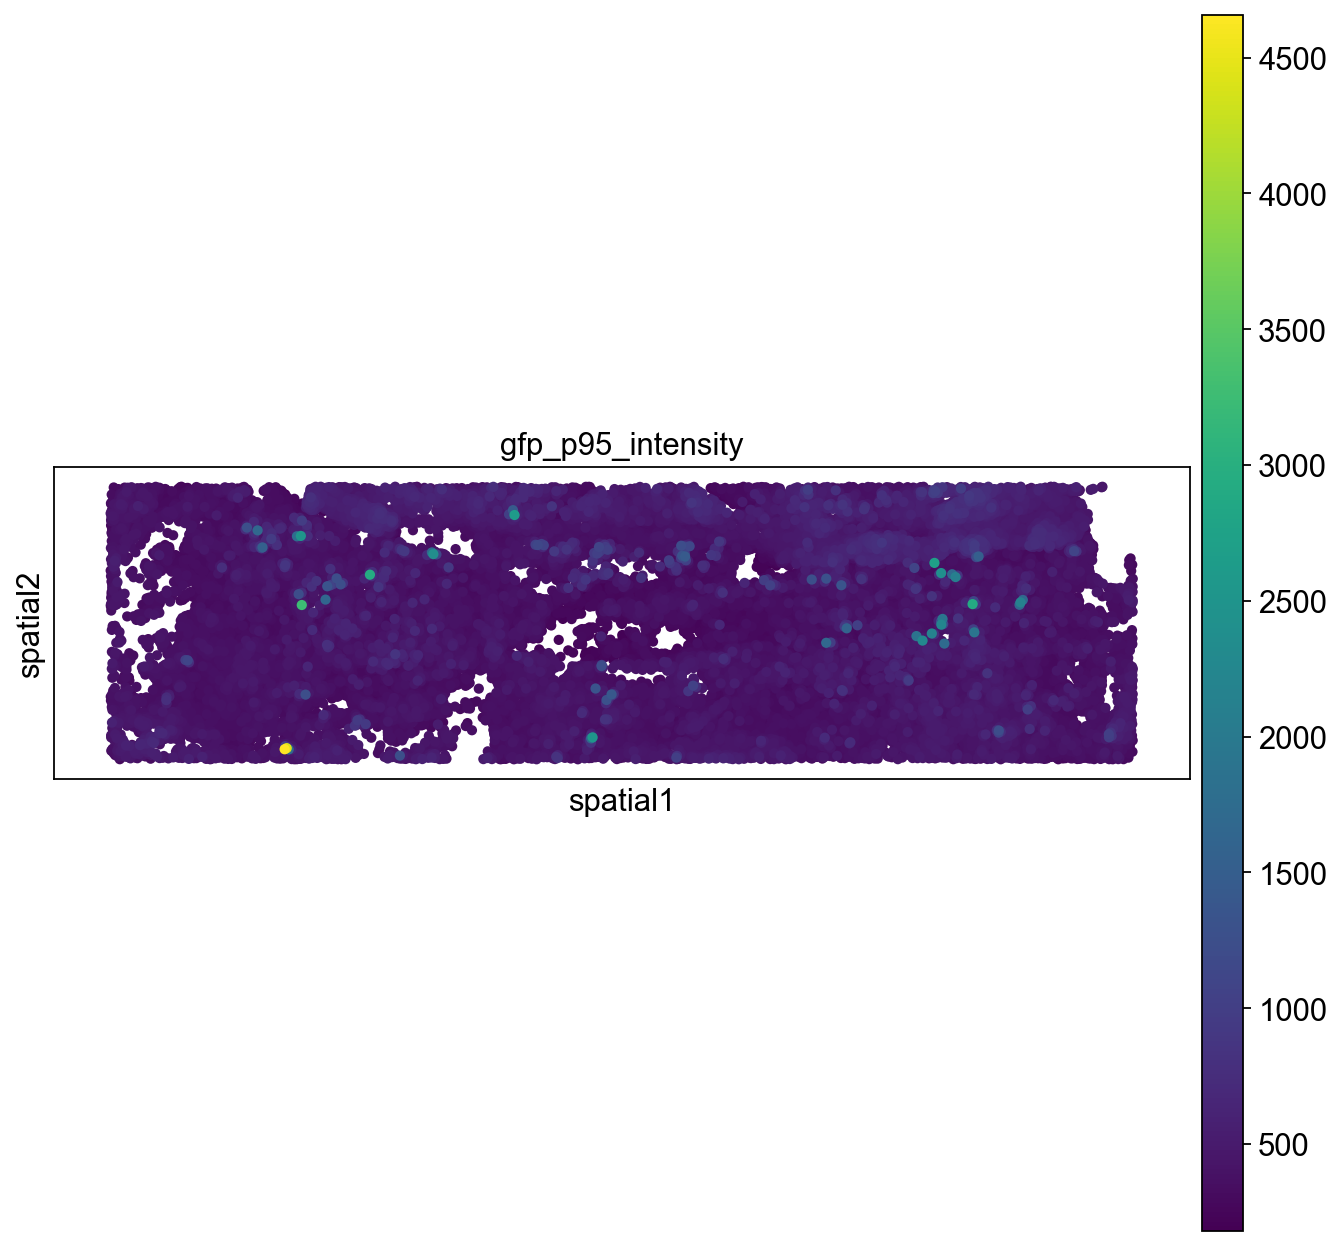

In [19]:
sc.pl.spatial(adata_full_corr, color=['gfp_p90_intensity'], spot_size=150)
sc.pl.spatial(adata_full_corr, color=['gfp_p99_intensity'], spot_size=150)
sc.pl.spatial(adata_full_corr, color=['gfp_p95_intensity'], spot_size=150)

In [2]:
adata_full_corr

NameError: name 'adata_full_corr' is not defined

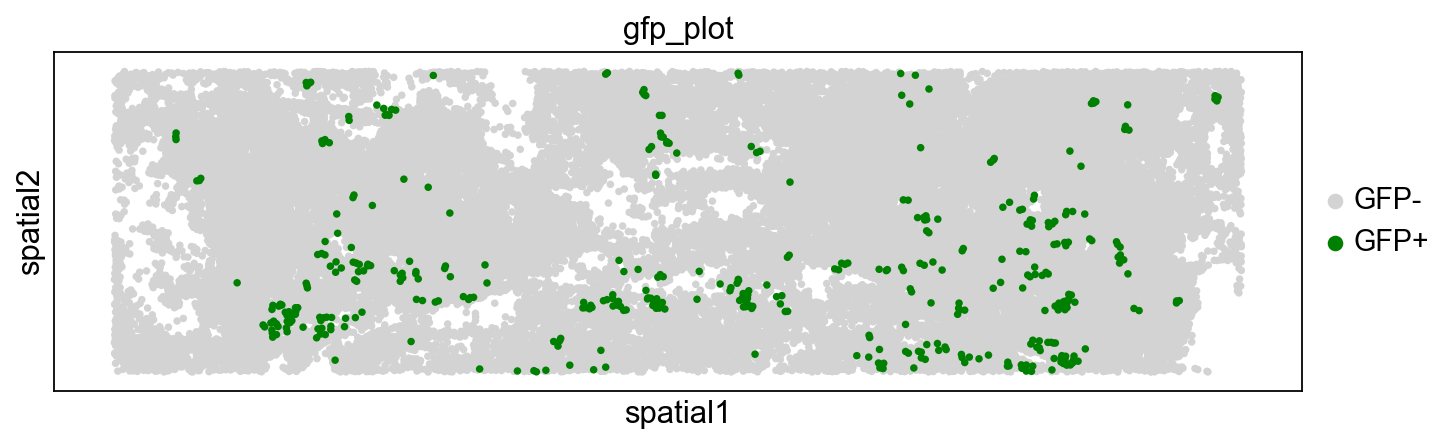

In [11]:
import pandas as pd
import scanpy as sc

adata_full_corr.obs["gfp_positive"] = (
    adata_full_corr.obs["gfp_p99_intensity"] > 800 
).astype(int)


adata_full_corr.obs["gfp_plot"] = pd.Categorical(
    adata_full_corr.obs["gfp_positive"].map({
        0: "GFP-",
        1: "GFP+",
    }),
    categories=["GFP-", "GFP+"],
    ordered=True,
)

adata_plot = adata_full_corr[
    adata_full_corr.obs.sort_values(
        "gfp_positive",
        ascending=True
    ).index
].copy()

sc.pl.spatial(
    adata_plot,
    color="gfp_plot",
    palette={
        "GFP-": "lightgrey",
        "GFP+": "green",
    },
    spot_size=100,
)

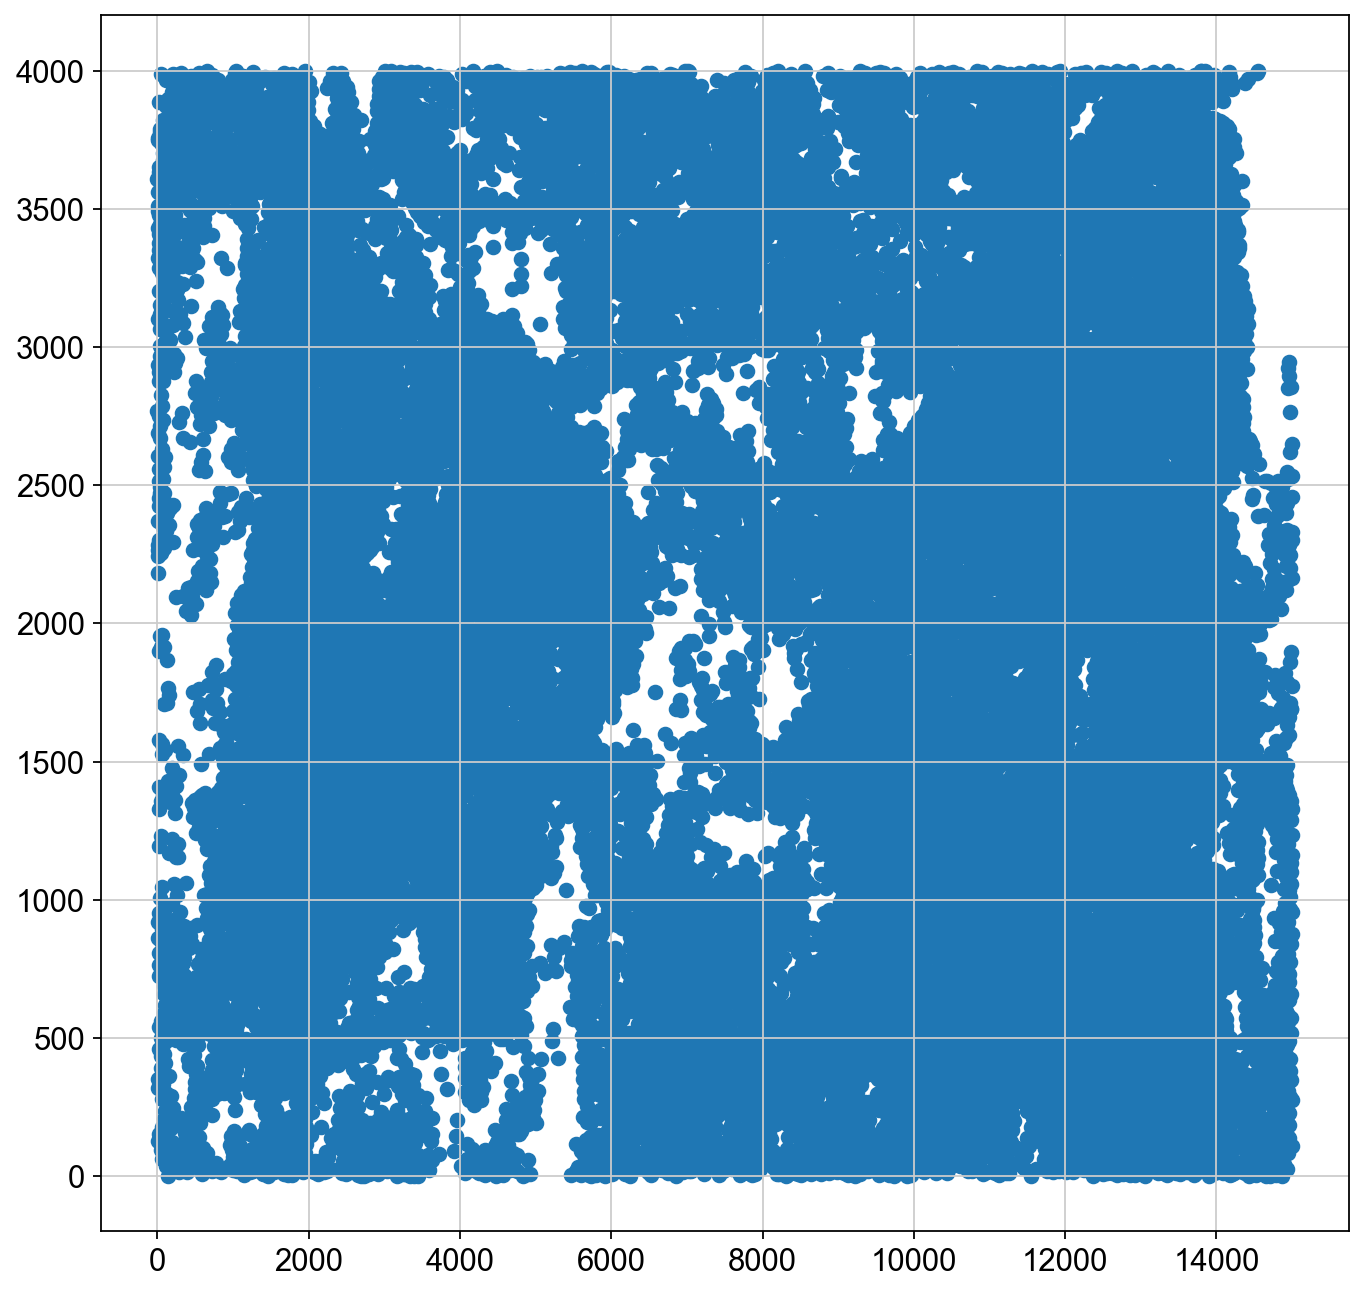

In [ ]:
plt.scatter(adata_plot.obsm['spatial'][:,0], adata_plot.obsm['spatial'][:,1])

In [20]:



import numpy as np

# GFP-positive cells
gfp_positive = adata_full_corr.obs["gfp_p99_intensity"].to_numpy() > 800

# Slc17a6 counts
slc17a6_counts = adata_full_corr[:, "Slc17a6"].X
if hasattr(slc17a6_counts, "toarray"):
    slc17a6_counts = slc17a6_counts.toarray().flatten()
else:
    slc17a6_counts = np.array(slc17a6_counts).flatten()

# GFP+ but no Slc17a6
mask_relabel = gfp_positive & (slc17a6_counts == 0)

# Reassign those cells
adata_full_corr.obs.loc[mask_relabel, "gfp_positive"] = 0

print(f"Relabeled {mask_relabel.sum()} GFP+ cells without Slc17a6")
import numpy as np

coords = adata_full_corr.obsm["spatial"]

x = coords[:, 0]
y = coords[:, 1]

x_cutoff = 11000
y_cutoff = 2000


remove_mask = (
    gfp_positive
    & (x < x_cutoff)
    & (y < y_cutoff)
)

adata_full_corr_filtered = adata_full_corr[~remove_mask].copy()



Relabeled 249 GFP+ cells without Slc17a6


In [23]:
adata_full_corr_filtered.obs["gfp_positive"] = adata_full_corr_filtered.obs["gfp_positive"].astype("category")

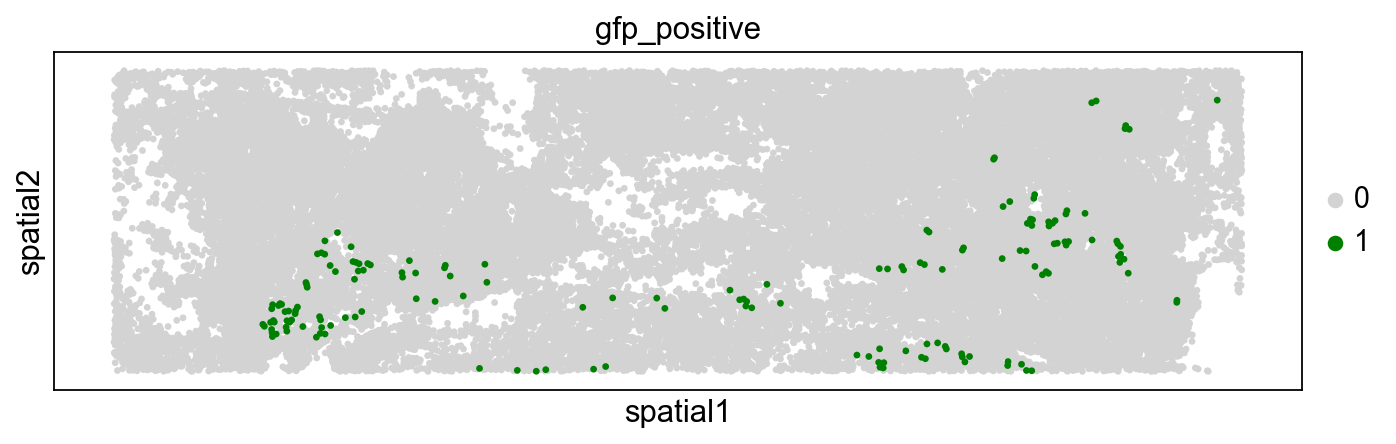

In [27]:
adata_plot = adata_full_corr_filtered[
    adata_full_corr_filtered.obs
    .sort_values("gfp_positive", ascending=True)
    .index
].copy()

sc.pl.spatial(
    adata_plot,  # use the sorted object
    color="gfp_positive",
    palette={
        0: "lightgrey",
        1: "green"}, 
    spot_size=90)

In [ ]:
# Initial GFP-positive call
adata_crop_cn_sub.obs["gfp_positive_raw"] = (
    (adata_crop_cn_sub.obs["gfp_max_intensity"] > 800) &
    (adata_crop_cn_sub.obs["gfp_median_intensity"] > 200)
)

# Cell barcodes manually identified as false positives
remove_gfp_cells = [
    # "cell_barcode_1",
    # "cell_barcode_2",
]

adata_crop_cn_sub.obs["gfp_manual_exclude"] = (
    adata_crop_cn_sub.obs_names.isin(remove_gfp_cells)
)

# Final GFP-positive assignment
adata_crop_cn_sub.obs["gfp_positive"] = (
    adata_crop_cn_sub.obs["gfp_positive_raw"] &
    ~adata_crop_cn_sub.obs["gfp_manual_exclude"]
).astype(int)

print(
    pd.crosstab(
        adata_crop_cn_sub.obs["gfp_positive_raw"],
        adata_crop_cn_sub.obs["gfp_positive"]
    )
)

In [ ]:
adata_full_corr

AnnData object with n_obs × n_vars = 32538 × 31
    obs: 'cell_number', 'gfp_mean_intensity', 'gfp_median_intensity', 'gfp_std_intensity', 'gfp_max_intensity', 'gfp_sum_intensity', 'gfp_p90_intensity', 'gfp_p95_intensity', 'gfp_p99_intensity', 'gfp_cv_intensity', 'gfp_top10_mean_intensity', 'gfp_n_pixels', 'gfp_n_pixels_above_300', 'gfp_fraction_pixels_above_300', 'gfp_n_pixels_above_500', 'gfp_fraction_pixels_above_500', 'gfp_positive'
    var: 'genes'
    obsm: 'spatial', 'spatial3d'

In [22]:
sc.pp.calculate_qc_metrics(
    adata_full_corr,percent_top=None, log1p=False, inplace=True
)
sc.pp.calculate_qc_metrics(
    adata_full_corr,percent_top=None, log1p=False, inplace=True
)
sc.pp.filter_cells(adata_full_corr, min_counts=10)
sc.pp.filter_cells(adata_full_corr, max_counts=300)

sc.pp.filter_genes(adata_full_corr, min_cells=10)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


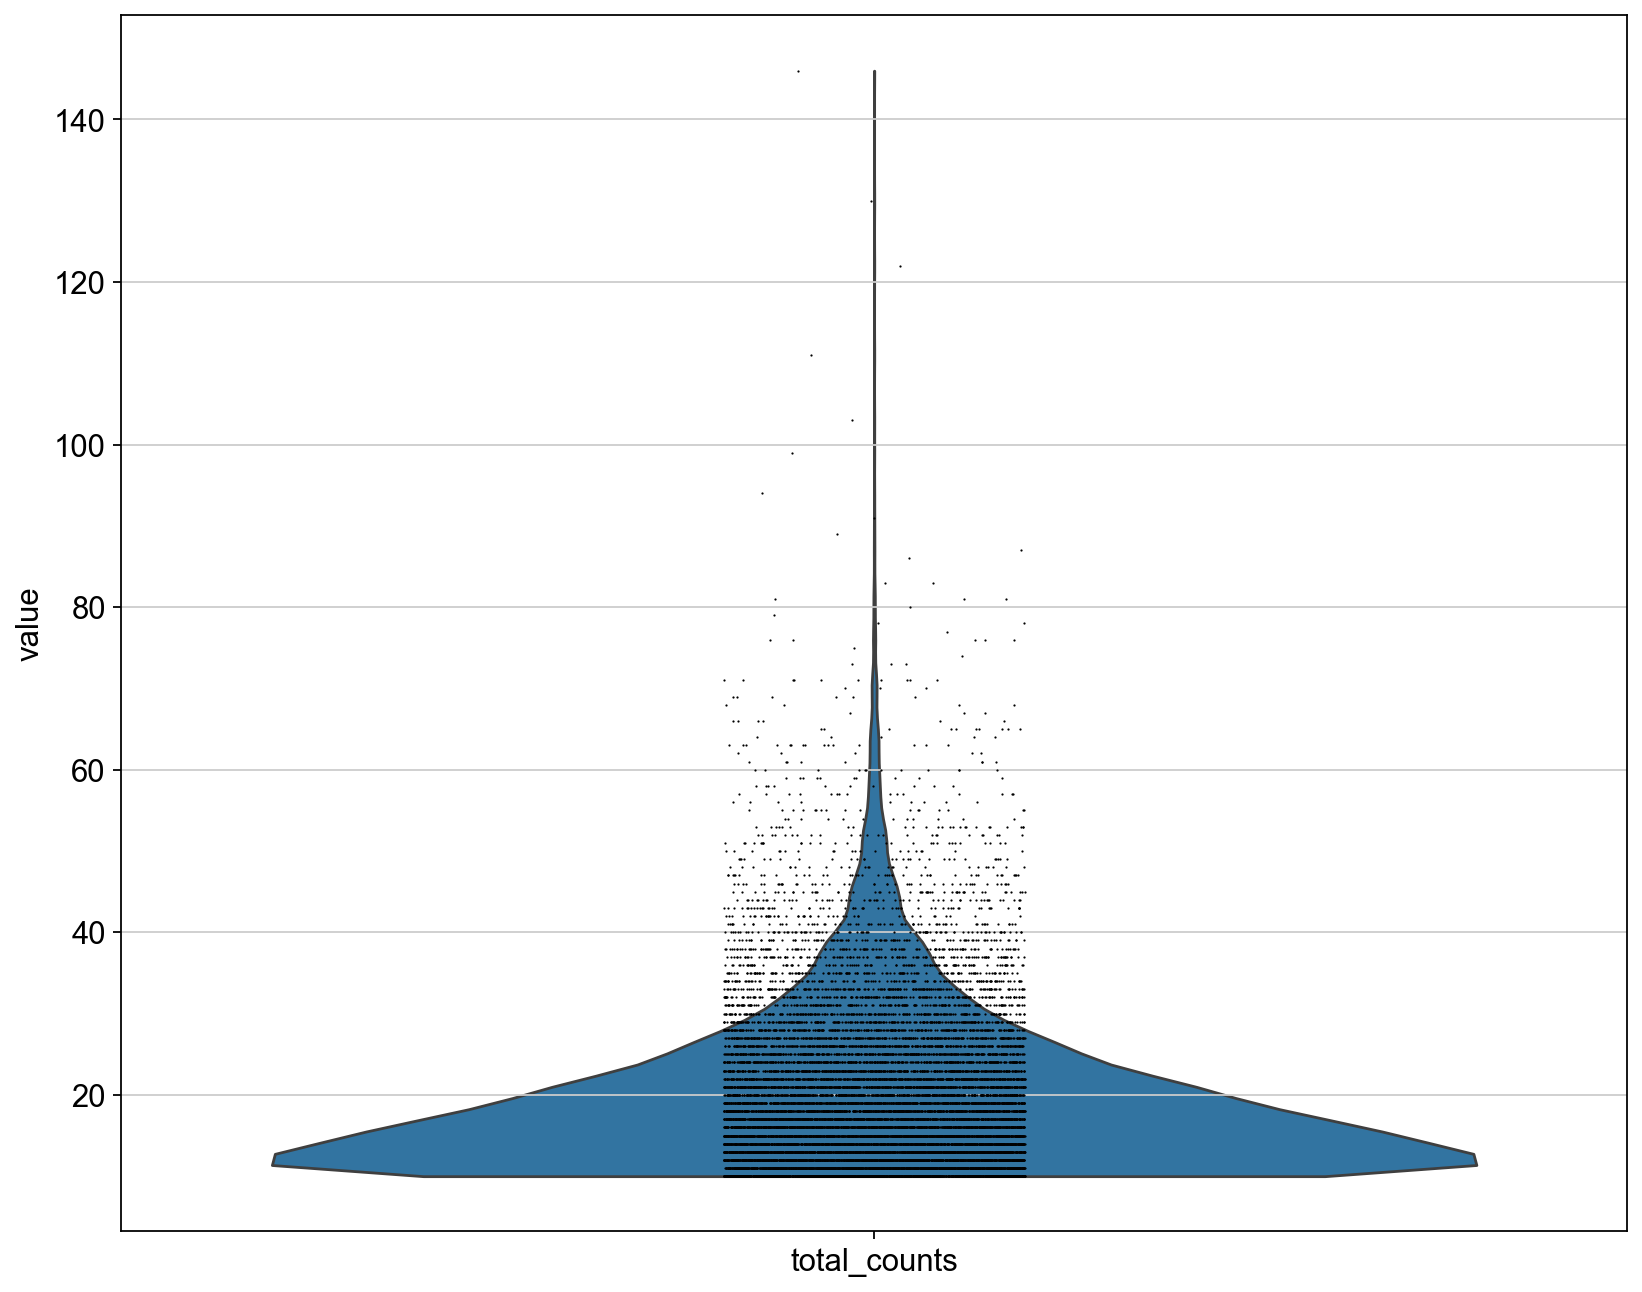

In [23]:
sc.pl.violin(adata_full_corr, keys=["total_counts"])

In [24]:
import scanpy as sc
import squidpy as sq
import scipy.sparse as sp

# --- Load your spatial AnnData ---
# Replace with your own dataset
#adata = sq.datasets.visium_hne_adata()

# --- Preprocessing ---
#sc.pp.calculate_qc_metrics(adata_full_corr, inplace=True)
sc.pp.normalize_total(adata_full_corr)
#sc.pp.log1p(adata)
#sc.pp.highly_variable_genes(adata)
#adata = adata[:, adata.var.highly_variable]

# PCA for transcriptomic representation
sc.pp.pca(adata_full_corr)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_full_corr, use_rep="X_pca", n_neighbors=10)  # adjustable


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


KeyError: 'Could not find key gfp_positive in .var_names or .obs.columns.'

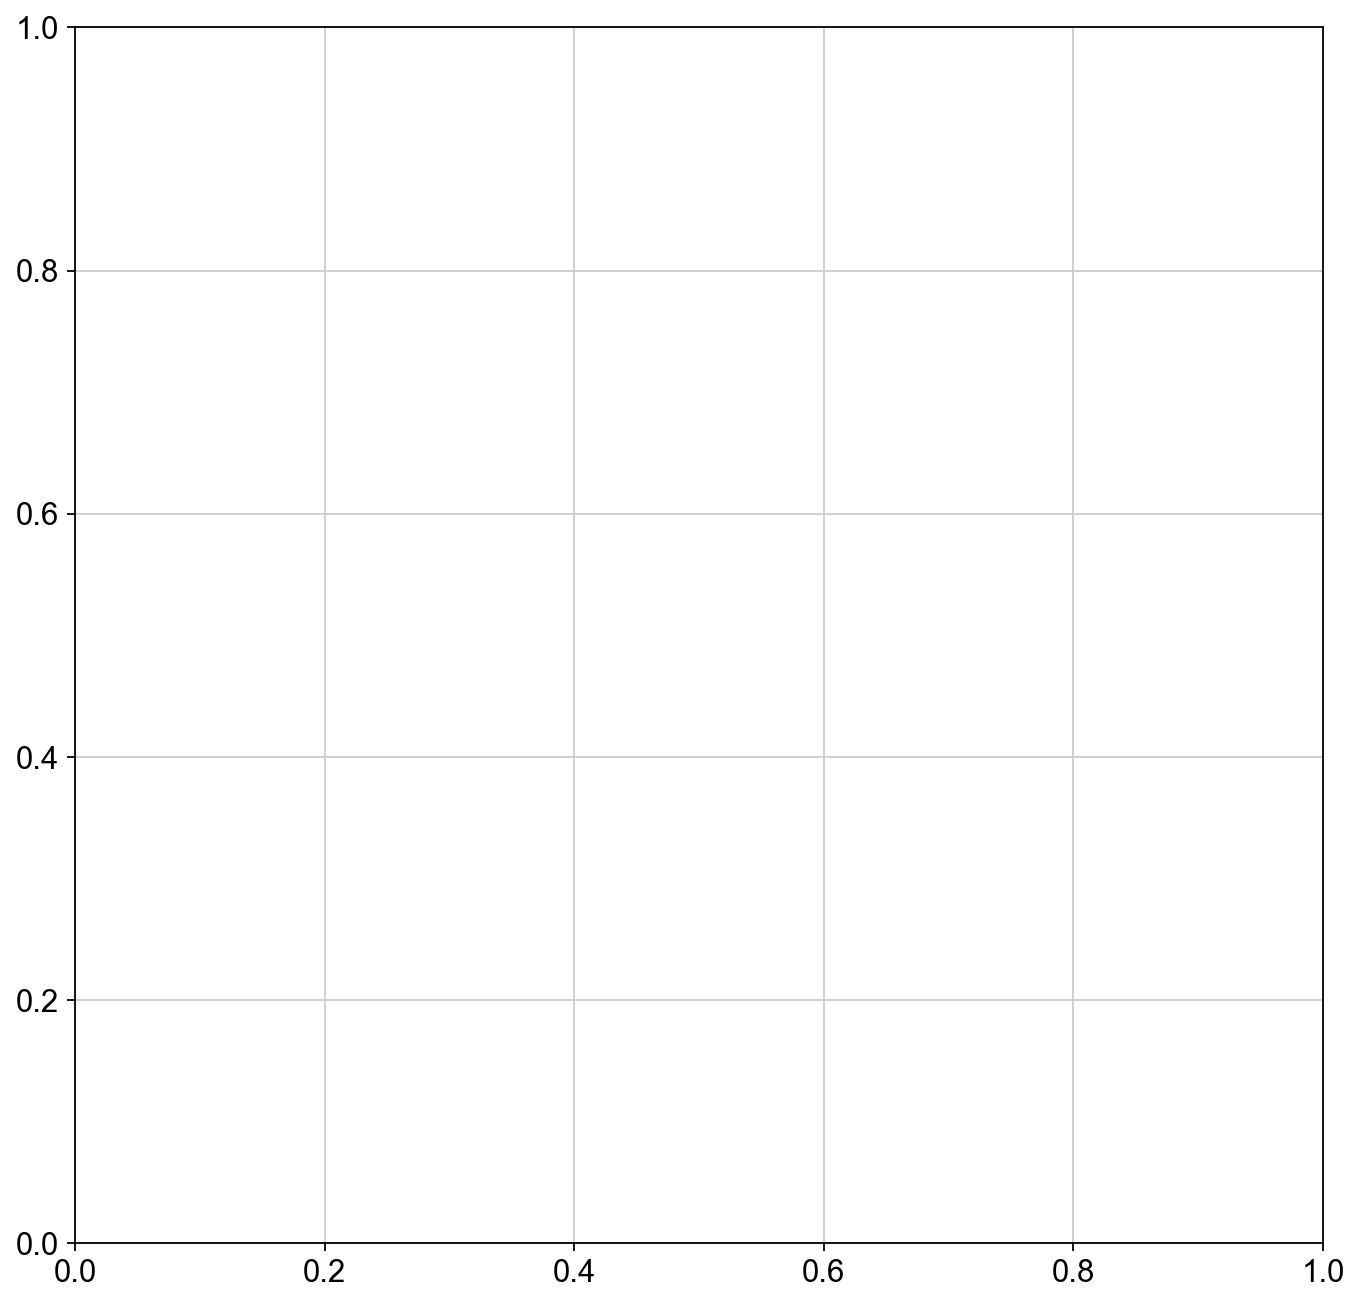

In [25]:
sc.pl.spatial(adata_full_corr, color = "gfp_positive", spot_size=100, vmax = 1)


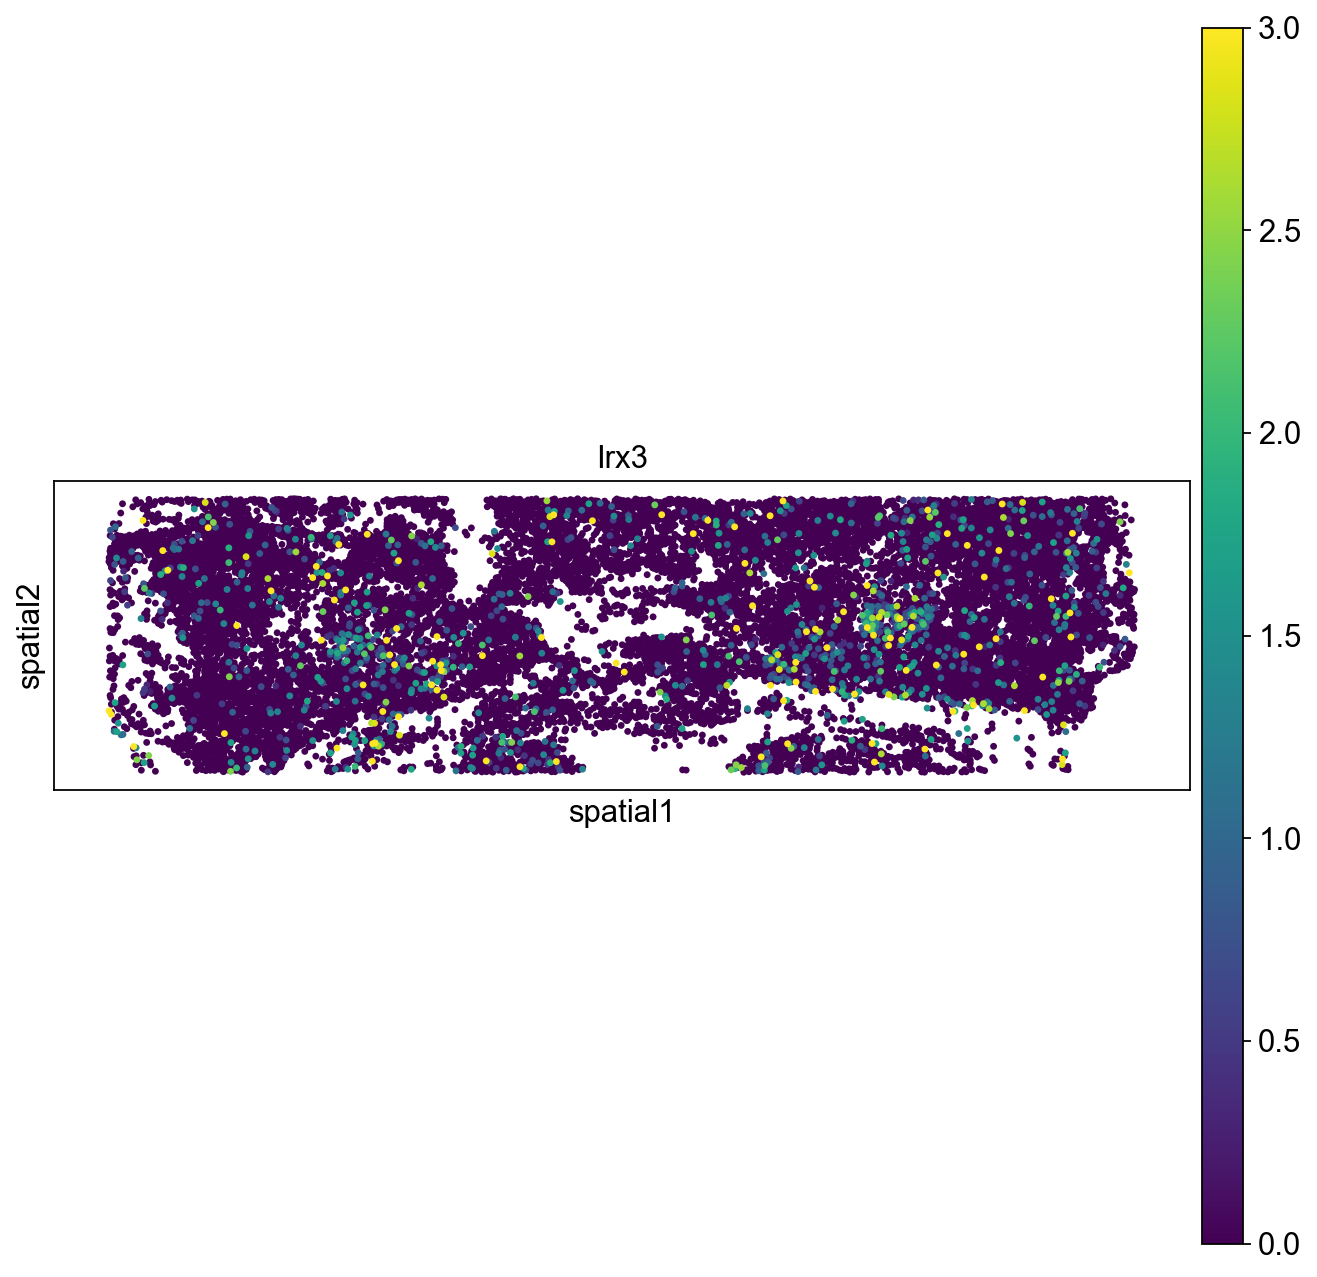

In [ ]:
sc.pl.spatial(adata_full_corr, color = "Irx3", spot_size=100, vmax = 3)


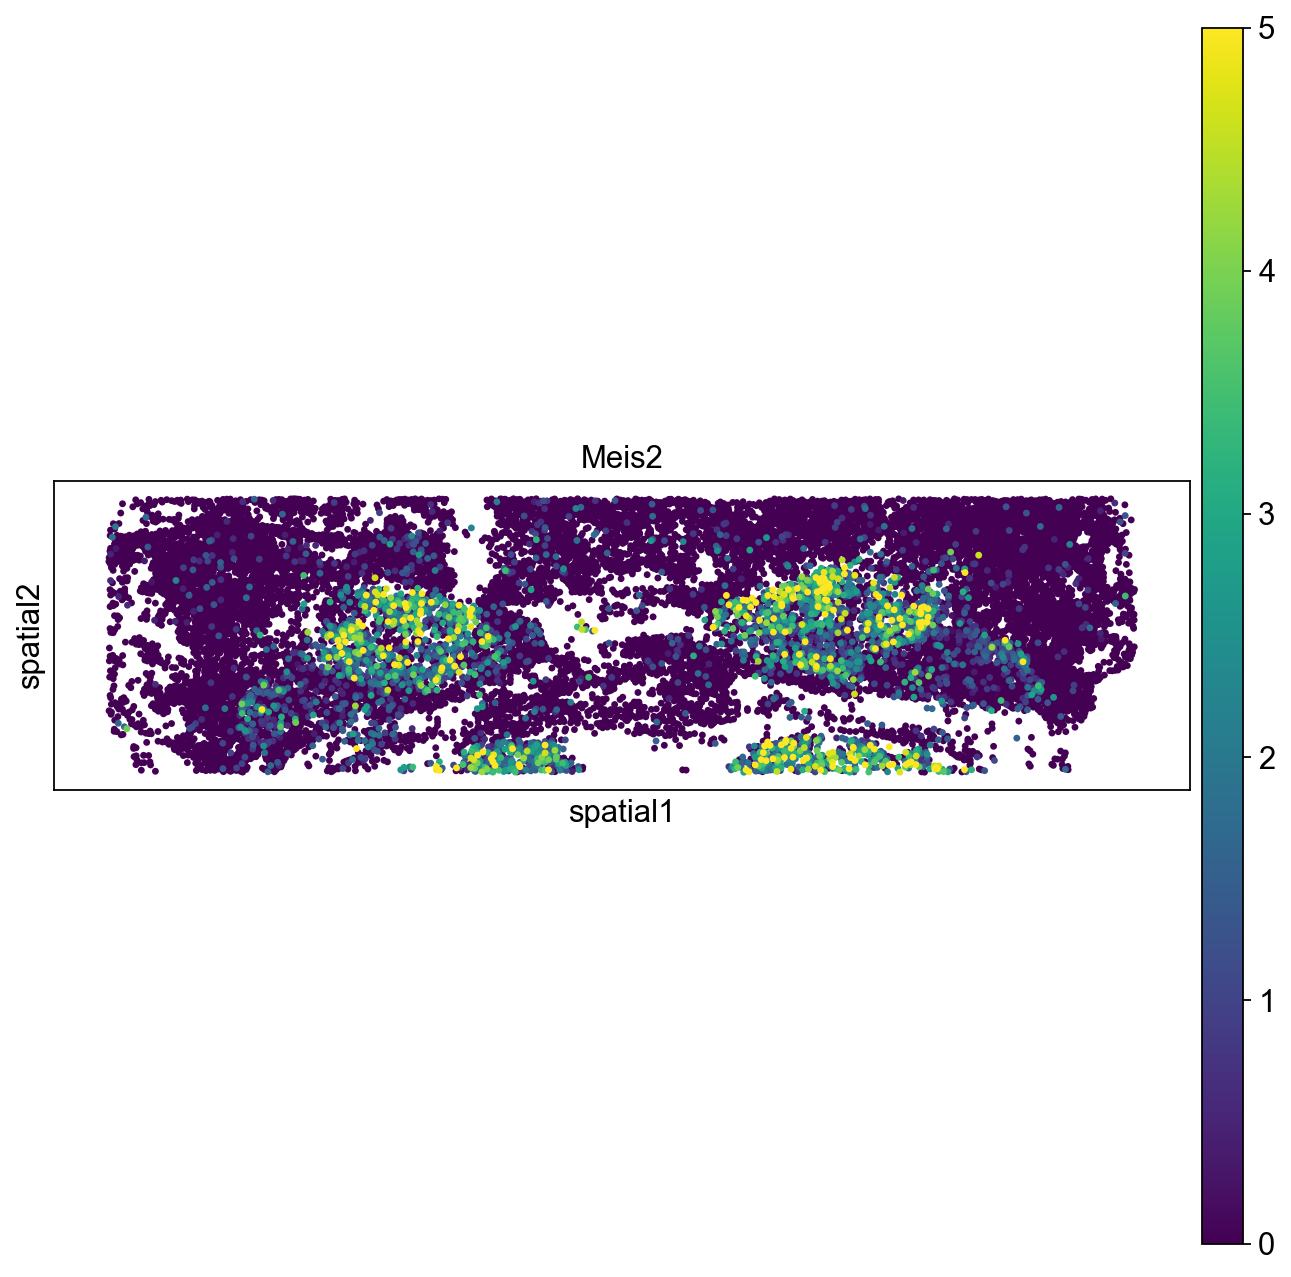

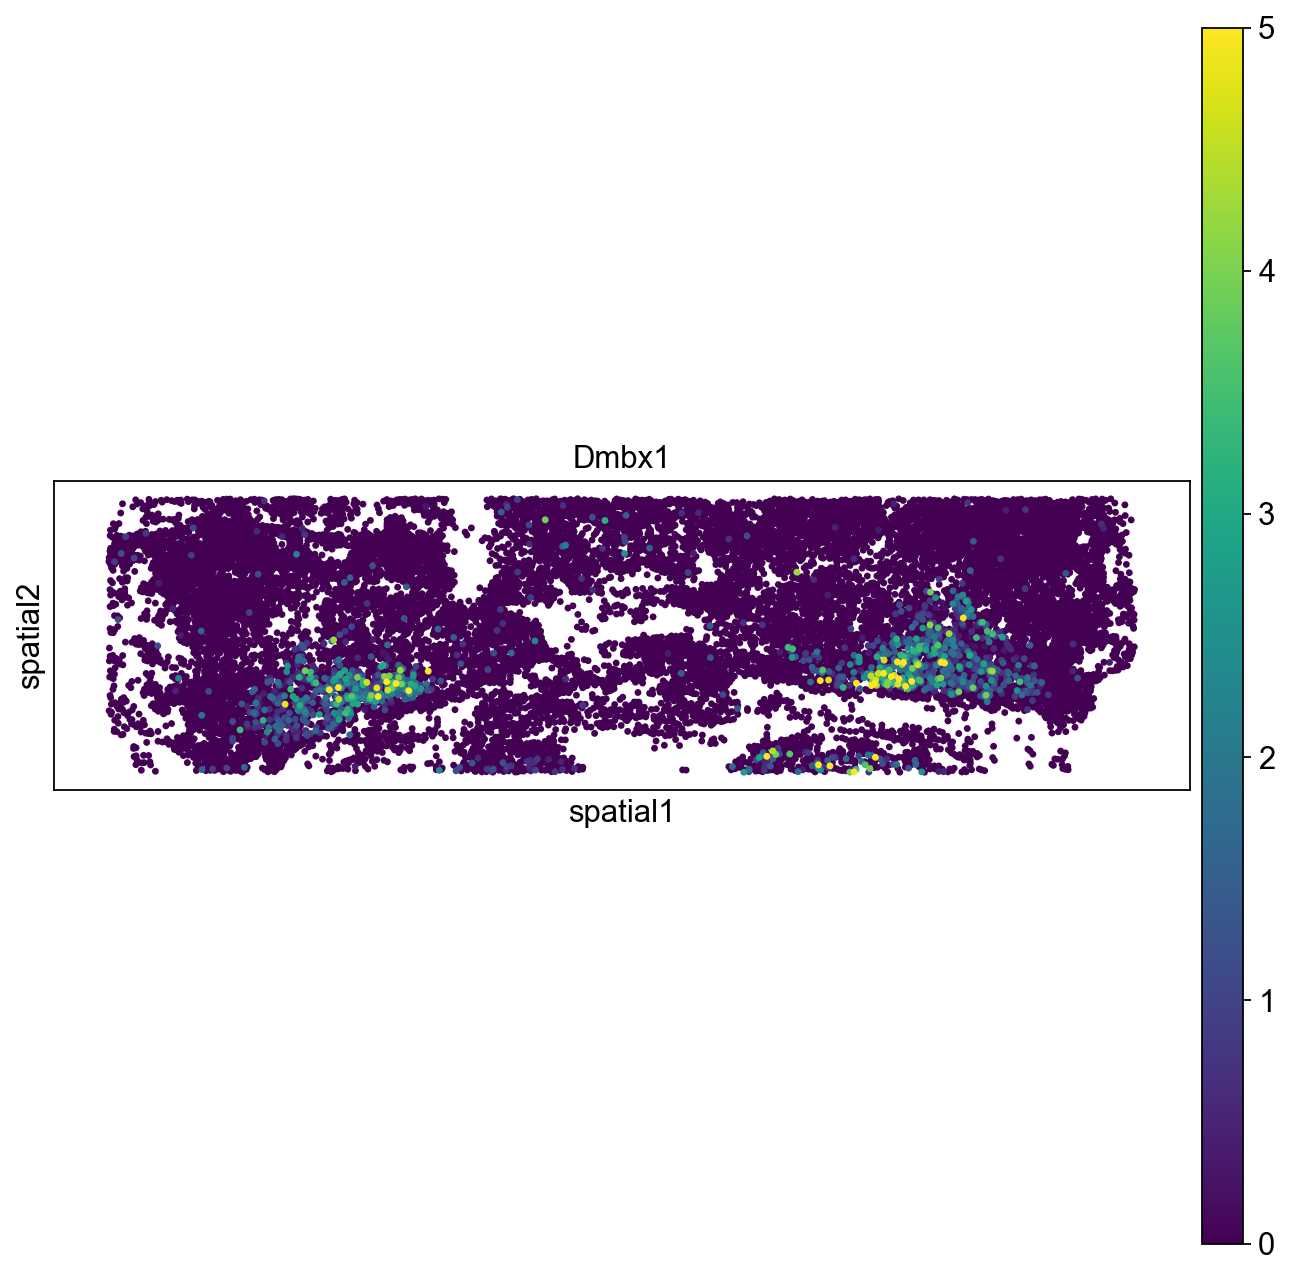

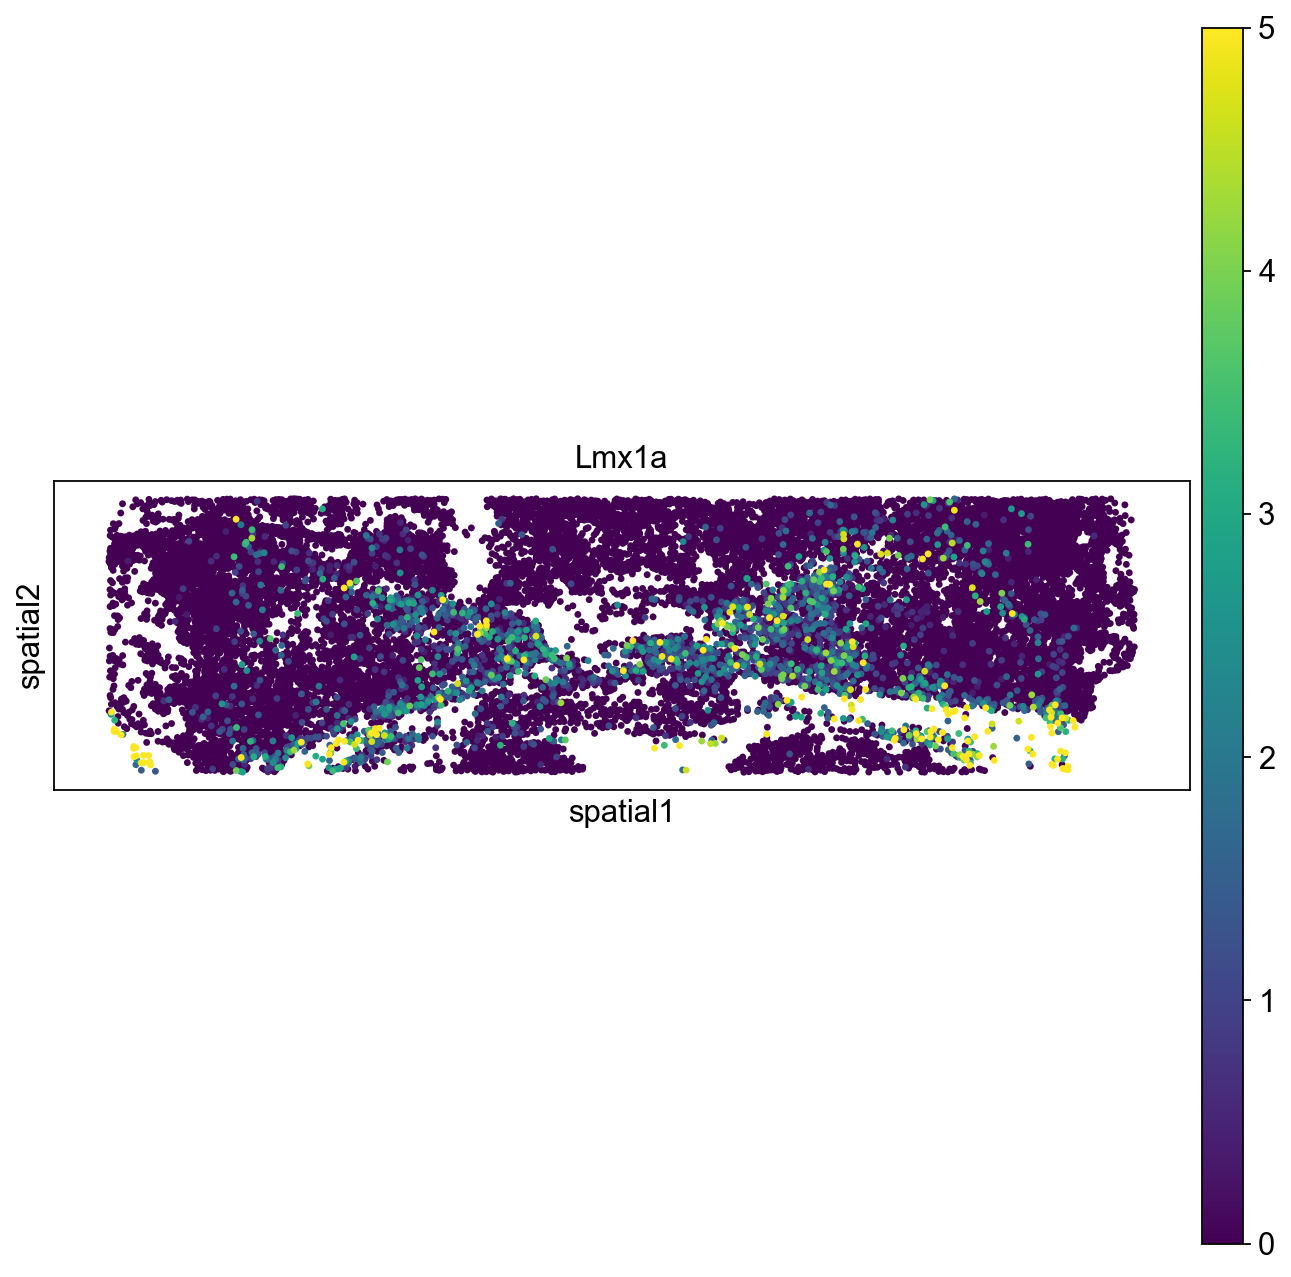

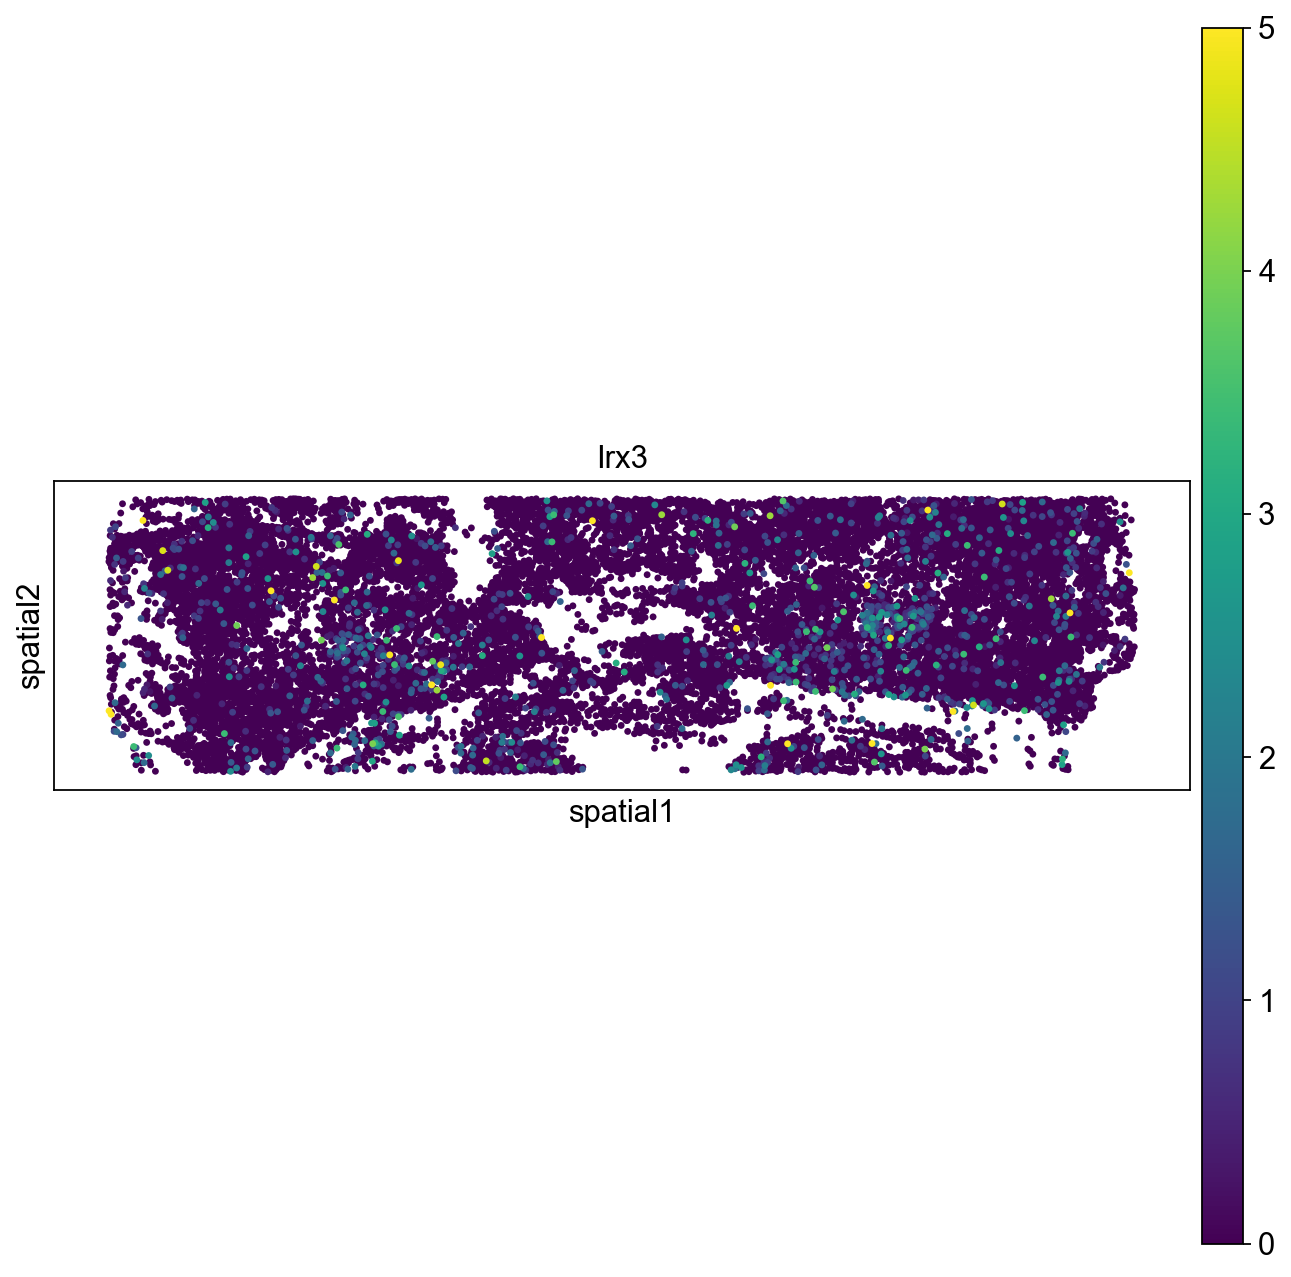

In [ ]:
sc.pl.spatial(adata_full_corr, color = "Meis2", spot_size=100, vmax = 5)
sc.pl.spatial(adata_full_corr, color = "Dmbx1", spot_size=100, vmax = 5)
sc.pl.spatial(adata_full_corr, color = "Lmx1a", spot_size=100, vmax = 5)
sc.pl.spatial(adata_full_corr, color = "Irx3", spot_size=100, vmax = 5)

#sc.pl.spatial(adata_full_corr, color = "gfp_positive", spot_size=100, vmax = 1)


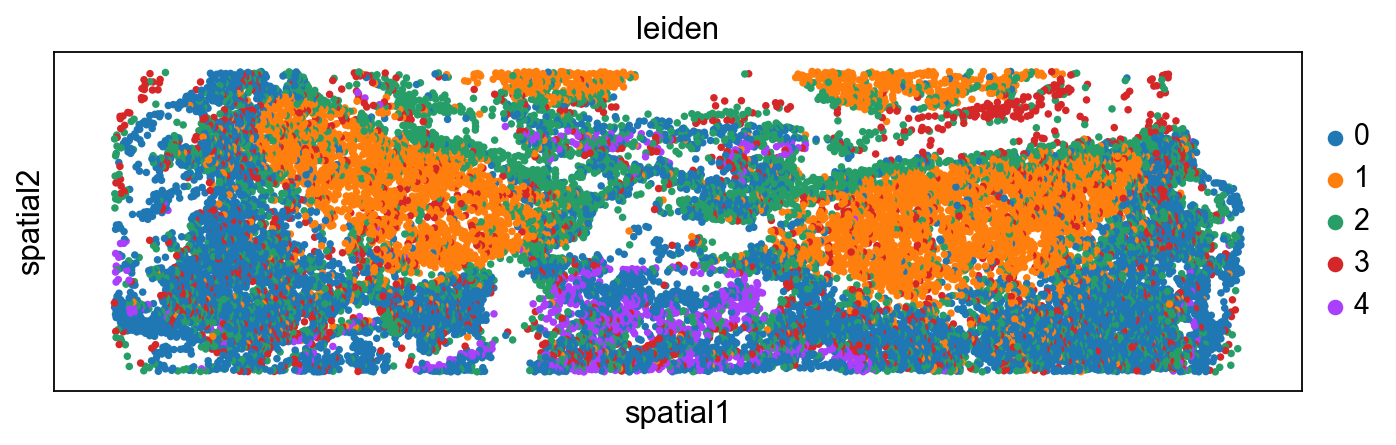

In [28]:
# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_full_corr,  resolution=0.3)

# --- Visualization ---
sc.pl.spatial(adata_full_corr, color = "leiden", spot_size=100)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


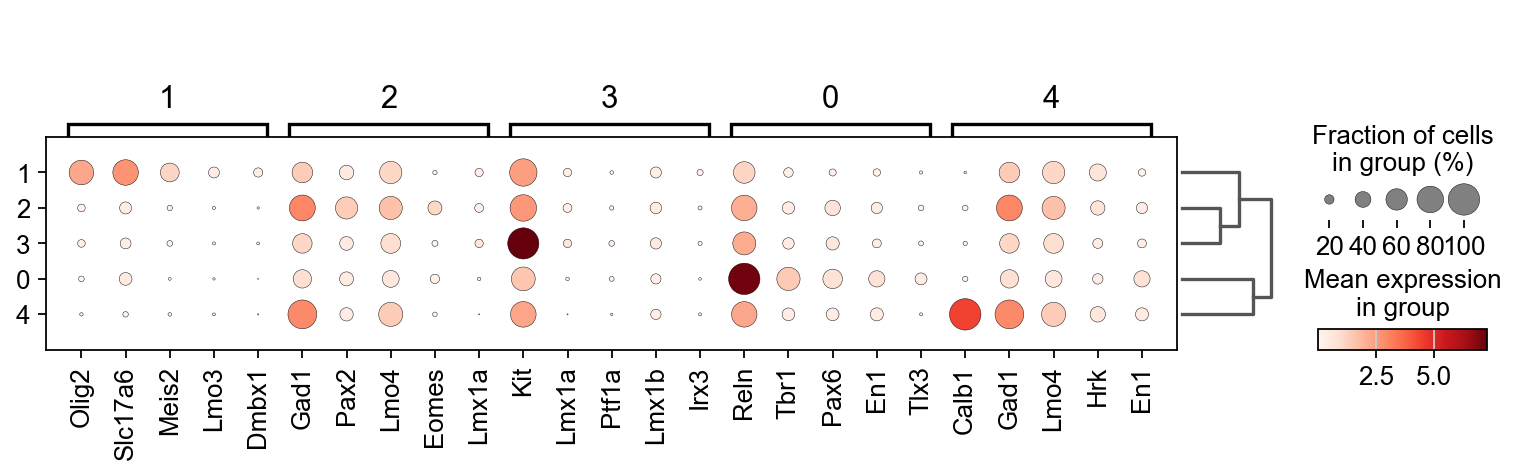

In [29]:
sc.tl.dendrogram(adata_full_corr, groupby="leiden")
sc.tl.rank_genes_groups(adata_full_corr, 'leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_full_corr, n_genes=5, key="wilcoxon", groupby="leiden")

In [30]:
adata_crop_cn = adata_full_corr[adata_full_corr.obs['leiden'].isin(['1'])]


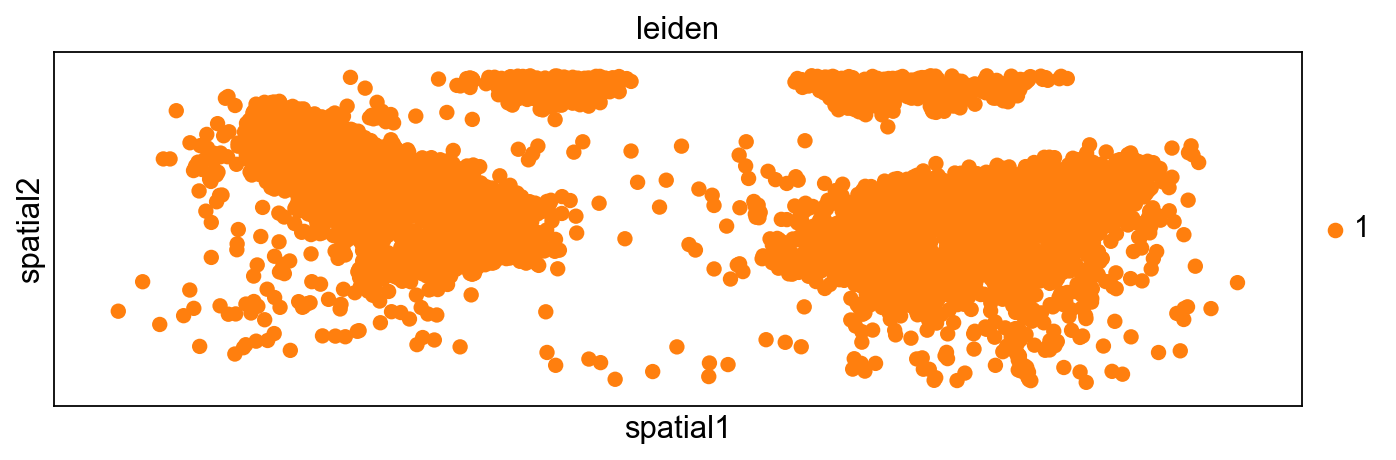

In [31]:
sc.pl.spatial(adata_crop_cn, color = "leiden", spot_size = 200)

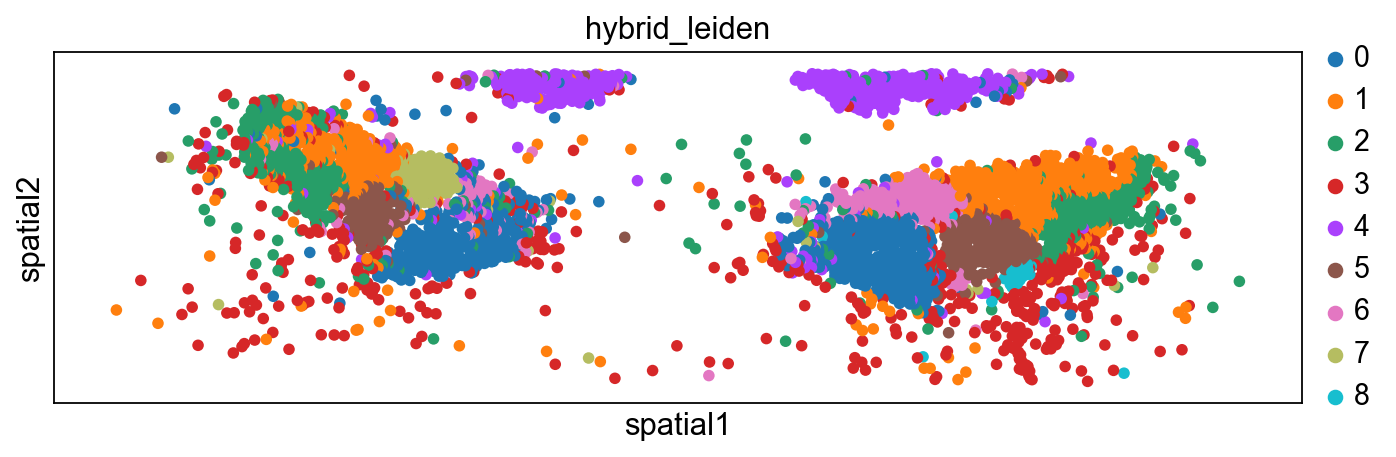

In [32]:
# PCA for transcriptomic representation
sc.pp.pca(adata_crop_cn)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_crop_cn, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_crop_cn.obsm['generic'] = adata_crop_cn.obsm['spatial']
sq.gr.spatial_neighbors(adata_crop_cn, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_crop_cn.obsp['connectivities']
spatial_graph = adata_crop_cn.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.8  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_crop_cn, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=1)

# --- Visualization ---
sc.pl.spatial(adata_crop_cn, color=['hybrid_leiden'], spot_size=150)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


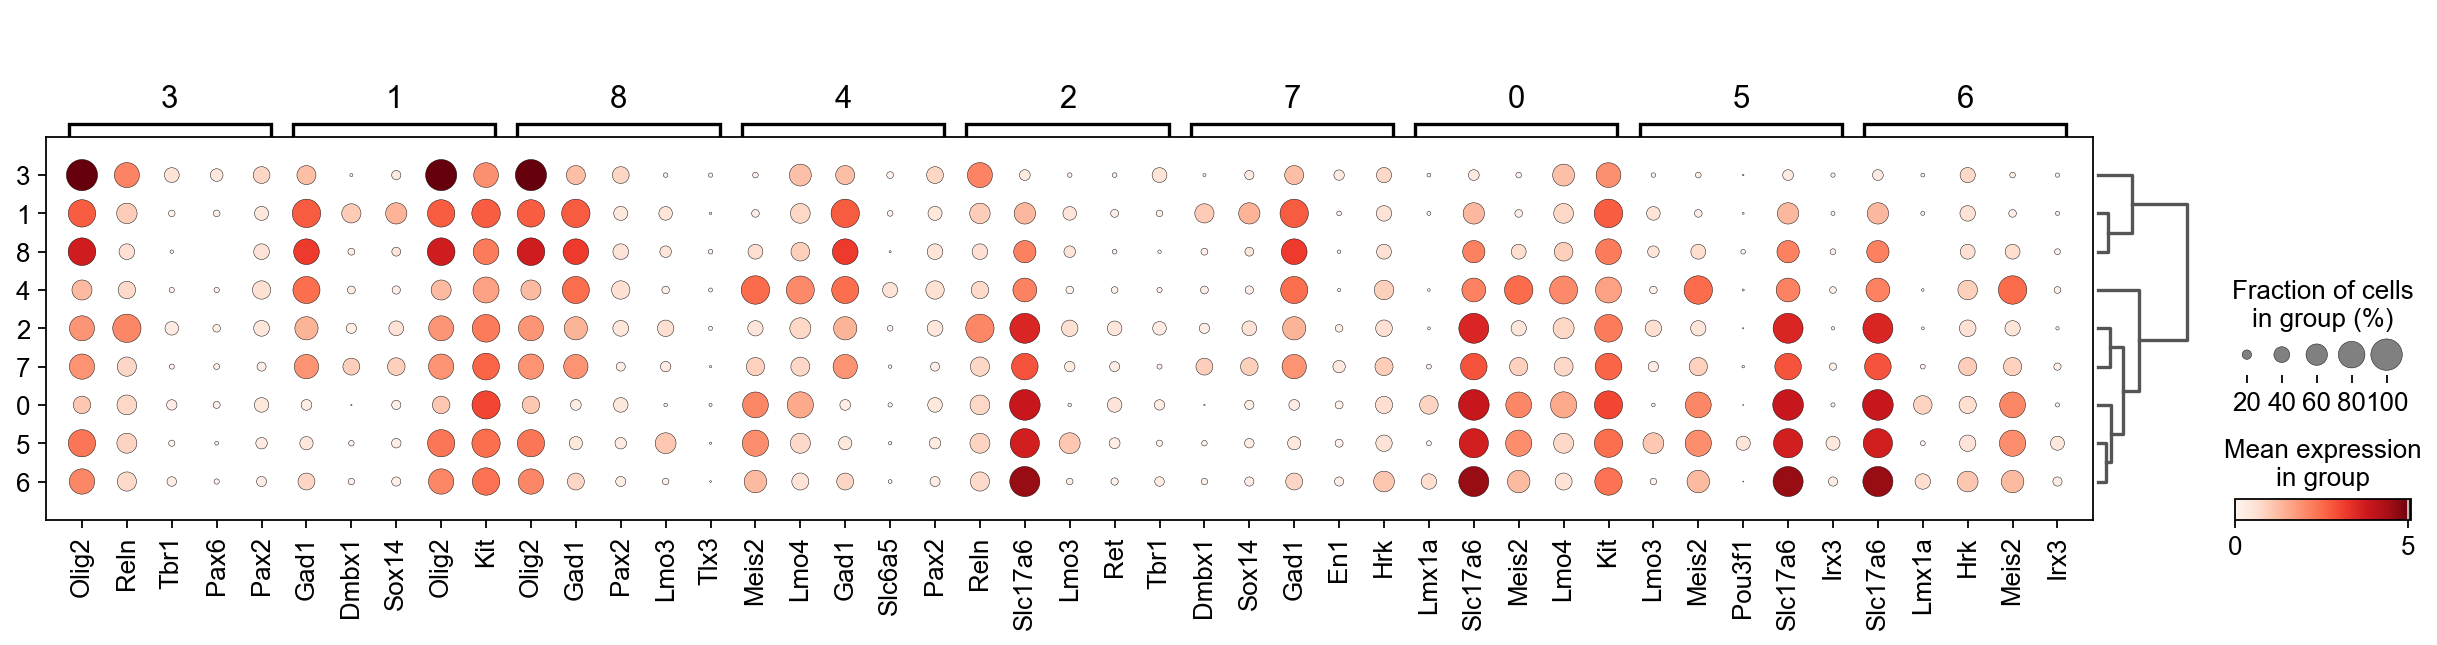

In [33]:
sc.tl.dendrogram(adata_crop_cn, groupby="hybrid_leiden")
sc.tl.rank_genes_groups(adata_crop_cn, 'hybrid_leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn, n_genes=5, key="wilcoxon", groupby="hybrid_leiden")

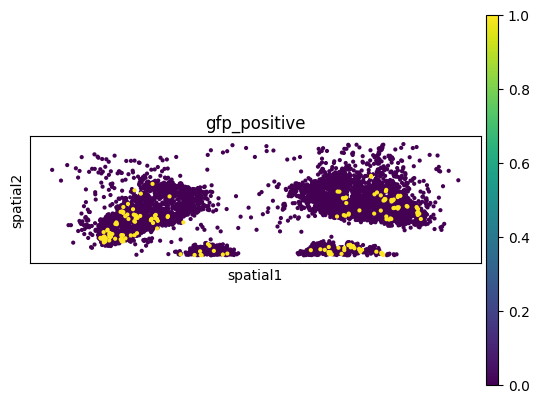

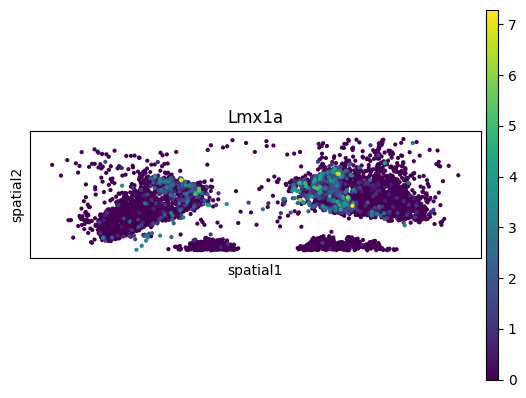

In [ ]:

sc.pl.spatial(
    adata_crop_cn,
    color=["gfp_positive"],
    spot_size=150
)


sc.pl.spatial(
    adata_crop_cn,
    color=["Lmx1a"],
    spot_size=150
)

In [34]:
adata_crop_cn_sub = adata_crop_cn[adata_crop_cn.obs['hybrid_leiden'].isin(['5', '6', '0', '2','1', '7'])]


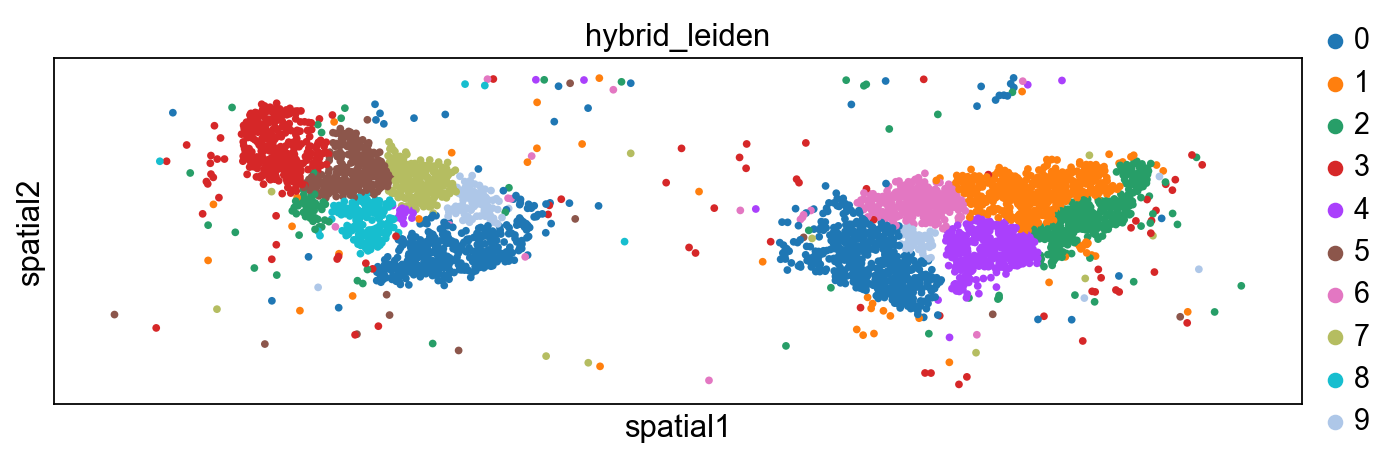

In [35]:
sc.set_figure_params(figsize = (10,10))
# PCA for transcriptomic representation
sc.pp.pca(adata_crop_cn_sub)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_crop_cn_sub, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_crop_cn_sub.obsm['generic'] = adata_crop_cn_sub.obsm['spatial']
sq.gr.spatial_neighbors(adata_crop_cn_sub, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_crop_cn_sub.obsp['connectivities']
spatial_graph = adata_crop_cn_sub.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.7  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_crop_cn_sub, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=0.9)

# --- Visualization ---
sc.pl.spatial(adata_crop_cn_sub, color=['hybrid_leiden'], spot_size=100)


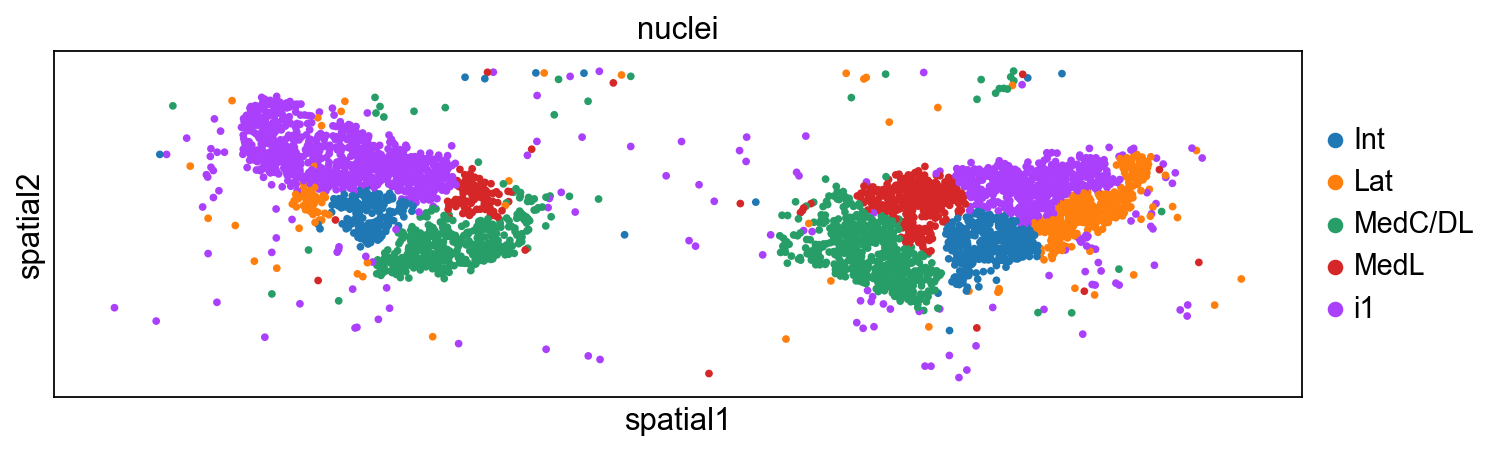

In [40]:
nucleus_map = {
    "2": "Lat",
    "3": "i1",
    "4": "Int",
    "8": "Int",
    "7": "i1",
    "5": "i1",
    "1": "i1",
    "0": "MedC/DL",
    "9": "MedL",
    "6": "MedL",
}

adata_crop_cn_sub.obs["nuclei"] = (
    adata_crop_cn_sub.obs["hybrid_leiden"]
    .astype(str)
    .map(nucleus_map)
    .astype("category")
)
sc.pl.spatial(adata_crop_cn_sub, color=['nuclei'], spot_size=100)


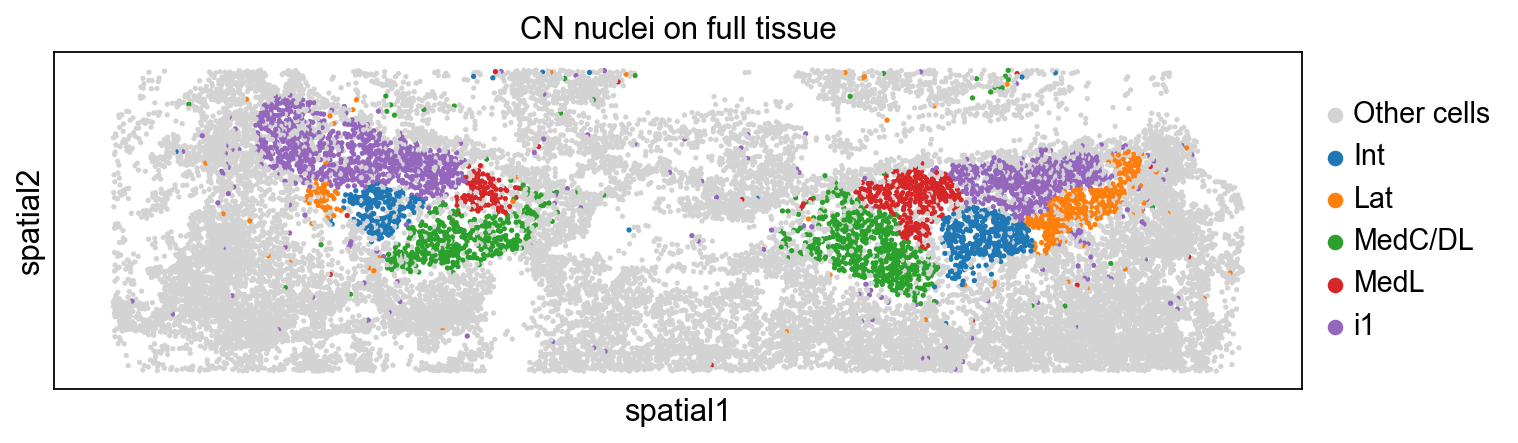

In [44]:

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

# initialize all cells as background
adata_full_corr.obs["nuclei_plot"] = "Other cells"

# copy nuclei labels onto matching cells
common_cells = adata_full_corr.obs_names.intersection(adata_crop_cn_sub.obs_names)

adata_full_corr.obs.loc[common_cells, "nuclei_plot"] = (
    adata_crop_cn_sub.obs.loc[common_cells, "nuclei"]
    .astype(str)
)

adata_full_corr.obs["nuclei_plot"] = adata_full_corr.obs["nuclei_plot"].astype("category")

# optional: put background first
cats = ["Other cells"] + [
    c for c in adata_full_corr.obs["nuclei_plot"].cat.categories
    if c != "Other cells"
]
adata_full_corr.obs["nuclei_plot"] = adata_full_corr.obs["nuclei_plot"].cat.reorder_categories(cats)


sc.pl.spatial(
    adata_full_corr,
    color="nuclei_plot",
    spot_size=70,
    palette=["lightgray"] + list(plt.cm.tab10.colors),
    title="CN nuclei on full tissue",
)

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


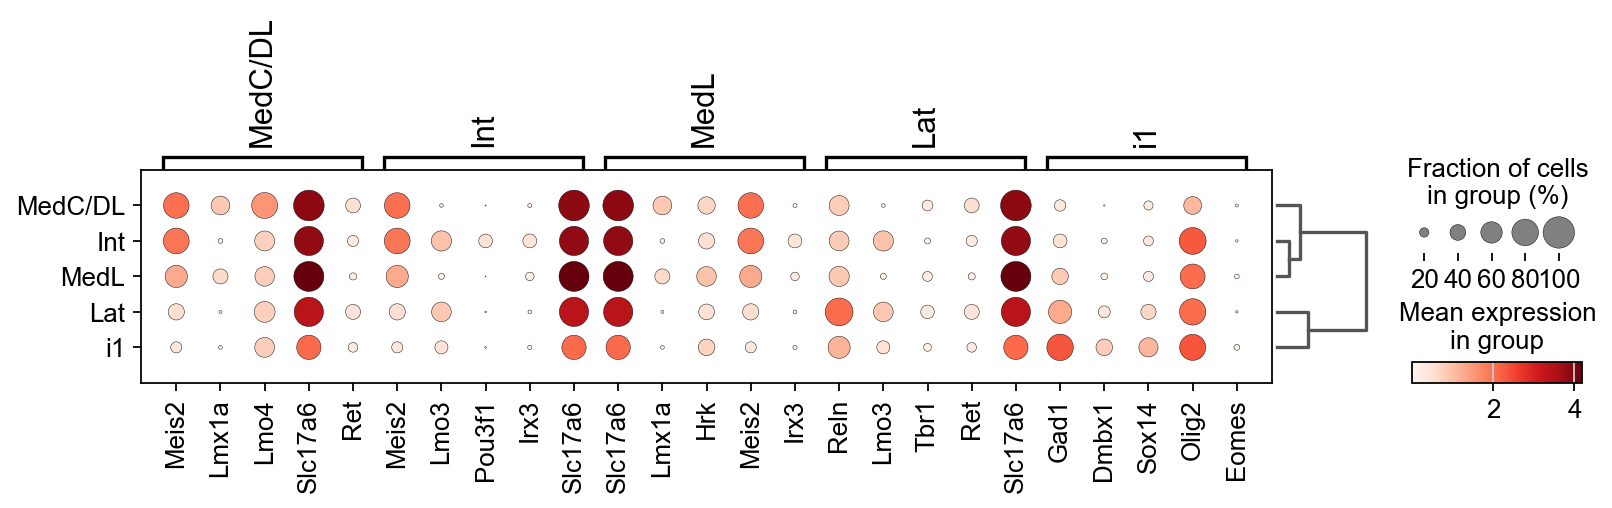

In [42]:
sc.tl.dendrogram(adata_crop_cn_sub, groupby="nuclei")
sc.tl.rank_genes_groups(adata_crop_cn_sub, 'nuclei', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn_sub, n_genes=5, key="wilcoxon", groupby="nuclei")

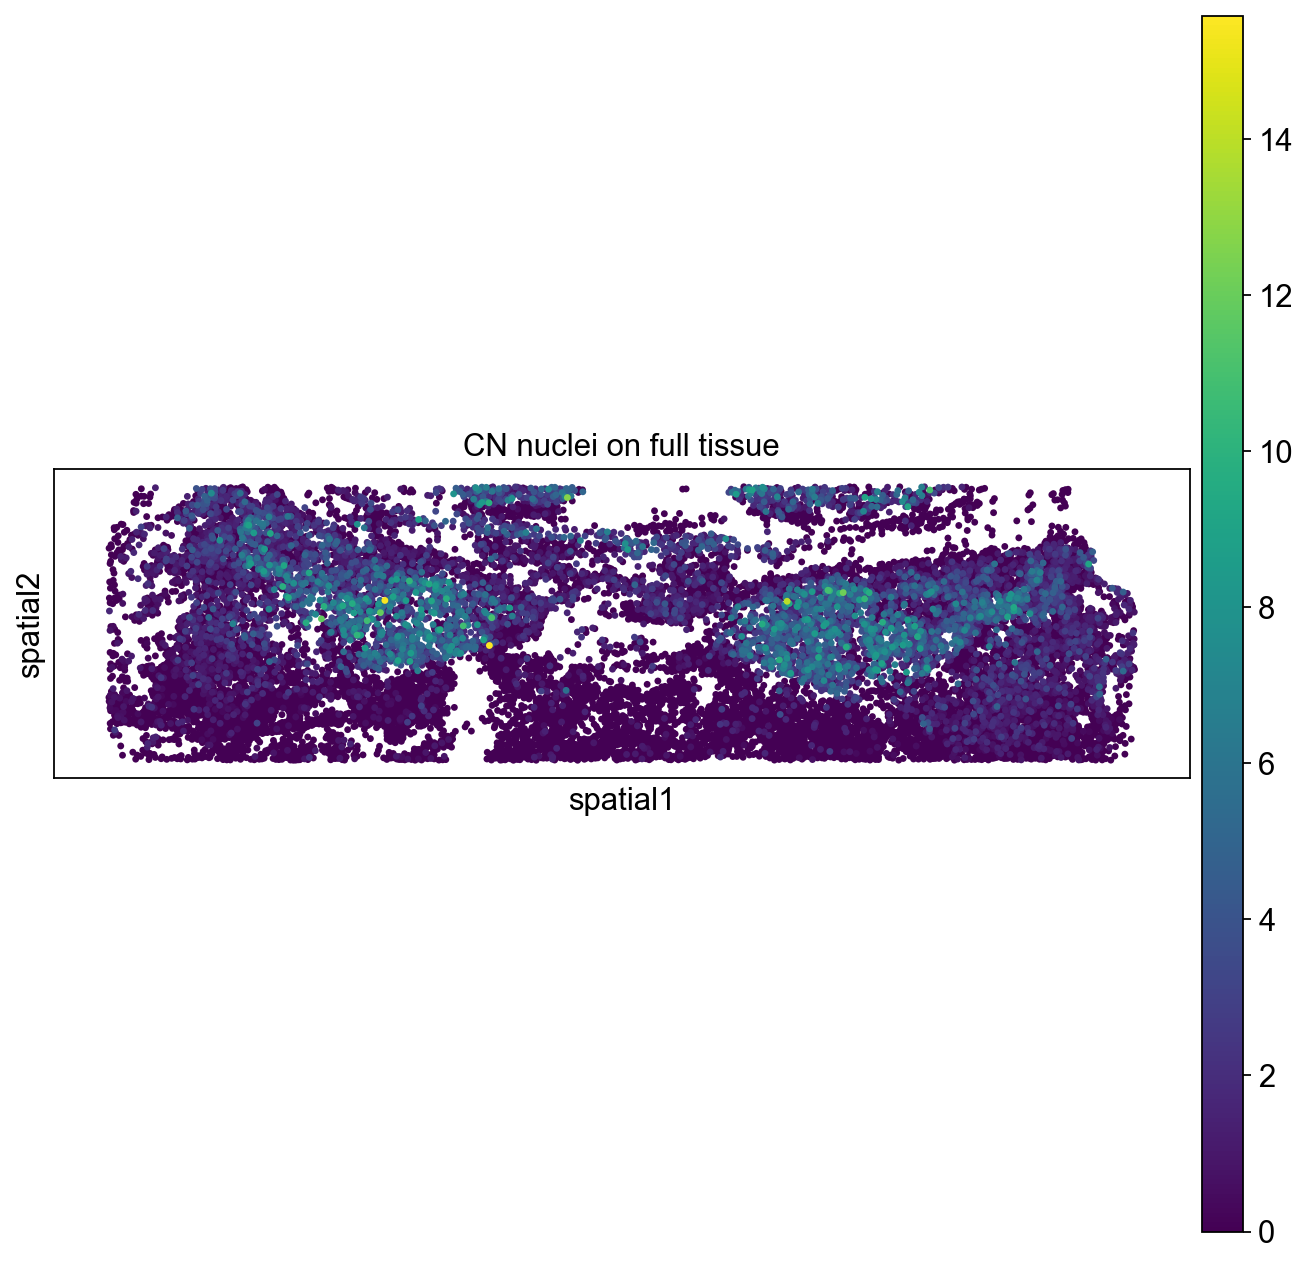

In [ ]:
sc.pl.spatial(
    adata_full_corr,
    color="Slc17a6",
    spot_size=100,
    #palette=["S"] + list(plt.cm.tab10.colors),
    title="CN nuclei on full tissue",
)

In [ ]:
adata_full_corr.obsm['spatial'][:,1] = np.max(adata_full_corr.obsm['spatial'][:,1]) - adata_full_corr.obsm['spatial'][:,1]

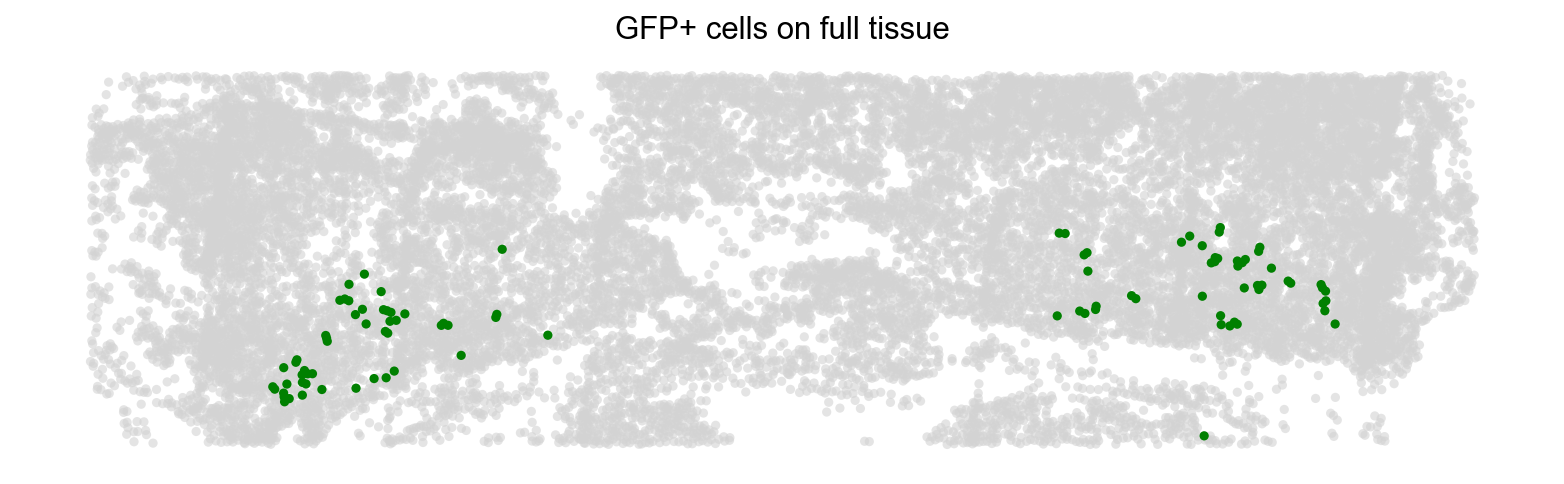

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

# Define GFP+ cells in the CN subset
adata_full_corr.obs["gfp_positive"] = (
    (adata_full_corr.obs["gfp_max_intensity"] > 1000) &
    (adata_full_corr.obs["gfp_median_intensity"] > 400)
).astype(int)

# Initialize labels in full object
adata_full_corr.obs["gfp_positive_plot"] = 0

# Transfer GFP calls by shared cell names
common_cells = adata_full_corr.obs_names.intersection(
    adata_crop_cn_sub.obs_names
)

adata_full_corr.obs.loc[common_cells, "gfp_positive_plot"] = (
    adata_crop_cn_sub.obs.loc[common_cells, "gfp_positive"]
    .astype(int)
    .to_numpy()
)

# Subset GFP+ cells
adata_gfp_pos = adata_full_corr[
    adata_full_corr.obs["gfp_positive_plot"] == 1
].copy()

fig, ax = plt.subplots(figsize=(10, 10))

# All cells in grey
n_before = len(ax.collections)

sc.pl.spatial(
    adata_full_corr,
    color=None,
    spot_size=100,
    ax=ax,
    show=False,
    frameon=False,
)

for collection in ax.collections[n_before:]:
    collection.set_facecolor("lightgrey")
    collection.set_edgecolor("none")
    collection.set_alpha(0.6)

# GFP+ cells in green
n_before = len(ax.collections)

sc.pl.spatial(
    adata_gfp_pos,
    color=None,
    spot_size=100,
    ax=ax,
    show=False,
    frameon=False,
)

for collection in ax.collections[n_before:]:
    collection.set_facecolor("green")
    collection.set_edgecolor("none")
    collection.set_alpha(1)
    collection.set_zorder(10)

ax.set_title("GFP+ cells on full tissue")
ax.set_axis_off()

plt.tight_layout()
plt.show()

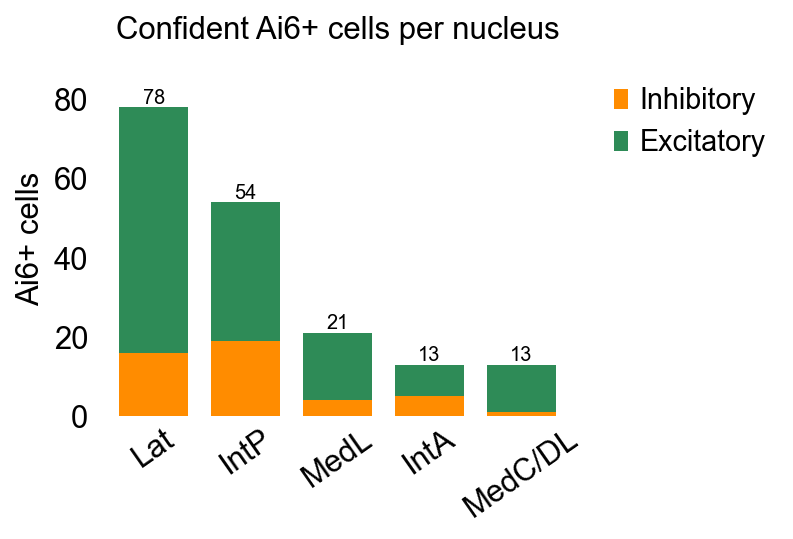

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

adata_plot = adata_full_corr

# --------------------------------------------------
# Transfer nucleus annotations from the CN subset
# --------------------------------------------------
adata_plot.obs["nuclei"] = np.nan

common_cells = adata_plot.obs_names.intersection(
    adata_crop_cn_sub.obs_names
)

adata_plot.obs.loc[common_cells, "nuclei"] = (
    adata_crop_cn_sub.obs.loc[common_cells, "nuclei"]
    .astype(str)
    .to_numpy()
)

# --------------------------------------------------
# Call Ai6/GFP+ cells
# --------------------------------------------------

adata_plot.obs["gfp_positive"] = (
    (adata_plot.obs["gfp_max_intensity"] > 800) &
    (adata_plot.obs["gfp_median_intensity"] > 200)
).astype(int)
# --------------------------------------------------
# Get Gad1 and Slc17a6 expression
# --------------------------------------------------
gad1 = adata_plot[:, "Gad1"].X
slc17a6 = adata_plot[:, "Slc17a6"].X

gad1 = (
    gad1.toarray().ravel()
    if hasattr(gad1, "toarray")
    else np.asarray(gad1).ravel()
)

slc17a6 = (
    slc17a6.toarray().ravel()
    if hasattr(slc17a6, "toarray")
    else np.asarray(slc17a6).ravel()
)

# Avoid divide-by-zero
eps = 1e-6
ratio = slc17a6 / (gad1 + eps)

adata_plot.obs["slc17a6_gad1_ratio"] = ratio

# --------------------------------------------------
# Assign confident marker classes
# --------------------------------------------------
adata_plot.obs["marker_class"] = pd.Series(
    pd.NA,
    index=adata_plot.obs_names,
    dtype="object",
)

adata_plot.obs.loc[
    adata_plot.obs["slc17a6_gad1_ratio"] > 1,
    "marker_class",
] = "Excitatory"

adata_plot.obs.loc[
    adata_plot.obs["slc17a6_gad1_ratio"] < 0.5,
    "marker_class",
] = "Inhibitory"

# --------------------------------------------------
# Keep only GFP+ cells that:
# 1. have a confident marker class
# 2. belong to an annotated CN nucleus
# --------------------------------------------------
gfp_obs = adata_plot.obs[
    (adata_plot.obs["gfp_positive"] == 1)
    & adata_plot.obs["marker_class"].notna()
    & adata_plot.obs["nuclei"].notna()
].copy()

count_df = (
    gfp_obs
    .groupby(["nuclei", "marker_class"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Add missing classes if necessary
for marker_class in ["Inhibitory", "Excitatory"]:
    if marker_class not in count_df.columns:
        count_df[marker_class] = 0

count_df = count_df[["Inhibitory", "Excitatory"]]

# Order nuclei by total confident GFP+ count
count_df = count_df.loc[
    count_df.sum(axis=1).sort_values(ascending=False).index
]

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(5.2, 3.6))

count_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.75,
    edgecolor="none",
    color={
        "Inhibitory": "darkorange",
        "Excitatory": "seagreen",
    },
)

# Add total count labels
totals = count_df.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total,
        str(int(total)),
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylabel("Ai6+ cells")
ax.set_xlabel("")
ax.set_title("Confident Ai6+ cells per nucleus", pad=10)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", rotation=35)
ax.grid(False)

ax.legend(
    frameon=False,
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.margins(y=0.15)

plt.tight_layout()
plt.show()

         GFP+ excitatory  Total excitatory  Percentage GFP+
nuclei                                                     
MedC/DL               12               764         1.570681
MedL                  17               305         5.573770
IntP                  35               328        10.670732
IntA                   8               406         1.970443
Lat                   62               452        13.716814


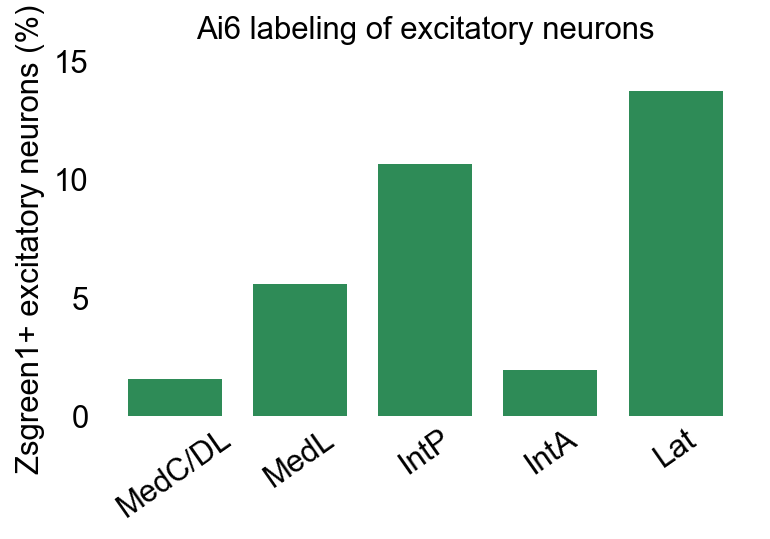

In [ ]:
# --------------------------------------------------
# Keep confidently classified excitatory cells
# assigned to a CN nucleus
# --------------------------------------------------
excitatory_obs = adata_plot.obs[
    (adata_plot.obs["marker_class"] == "Excitatory")
    & adata_plot.obs["nuclei"].notna()
].copy()

# Total excitatory cells per nucleus
total_excitatory = (
    excitatory_obs
    .groupby("nuclei", observed=True)
    .size()
)

# GFP+ excitatory cells per nucleus
gfp_excitatory = (
    excitatory_obs[
        excitatory_obs["gfp_positive"] == 1
    ]
    .groupby("nuclei", observed=True)
    .size()
)

# Percentage of excitatory cells that are GFP+
percentage_excitatory_gfp = (
    gfp_excitatory
    .reindex(total_excitatory.index, fill_value=0)
    .div(total_excitatory)
    .mul(100)
)

# Fixed anatomical order
nucleus_order = ["MedC/DL", "MedL", "IntP", "IntA", "Lat"]

percentage_excitatory_gfp = percentage_excitatory_gfp.reindex(
    [x for x in nucleus_order if x in percentage_excitatory_gfp.index]
)

summary_df = pd.DataFrame({
    "GFP+ excitatory": gfp_excitatory.reindex(
        percentage_excitatory_gfp.index,
        fill_value=0
    ),
    "Total excitatory": total_excitatory.reindex(
        percentage_excitatory_gfp.index
    ),
    "Percentage GFP+": percentage_excitatory_gfp,
})

print(summary_df)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(5.2, 3.6))

percentage_excitatory_gfp.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    edgecolor="none",
    color="seagreen",
)

# Add percentage labels


ax.set_ylabel("Zsgreen1+ excitatory neurons (%)")
ax.set_xlabel("")
ax.set_title("Ai6 labeling of excitatory neurons", pad=10)
ax.set_ylim(0, 15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", rotation=35)
ax.grid(False)
ax.margins(y=0.1)

plt.tight_layout()
plt.show()

GFP+ count      Total count      Percentage GFP+           
inhibitory_subtype         i1 i2/3          i1 i2/3              i1       i2/3
nuclei                                                                        
MedC/DL                     1    0          10   28       10.000000   0.000000
MedL                        3    1          19   12       15.789474   8.333333
IntP                       12    7         365   98        3.287671   7.142857
IntA                        1    4          19   35        5.263158  11.428571
Lat                        10    6          98   63       10.204082   9.523810

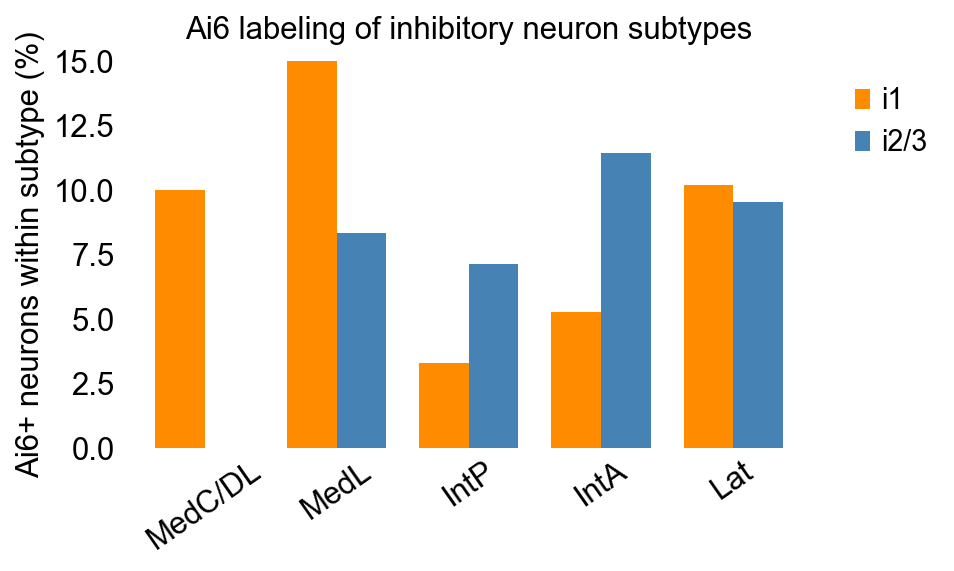

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

# --------------------------------------------------
# Helper function to extract gene expression
# --------------------------------------------------
def get_gene_vector(adata, gene):
    x = adata[:, gene].X

    return (
        x.toarray().ravel()
        if hasattr(x, "toarray")
        else np.asarray(x).ravel()
    )


# --------------------------------------------------
# Extract i1 marker expression
# --------------------------------------------------
sox14 = get_gene_vector(adata_plot, "Sox14")
dmbx1 = get_gene_vector(adata_plot, "Dmbx1")

adata_plot.obs["Sox14_expression"] = sox14
adata_plot.obs["Dmbx1_expression"] = dmbx1

# --------------------------------------------------
# Assign inhibitory subtypes
#
# i1:
# inhibitory and Sox14+, Dmbx1+, and/or Zfhx3+
#
# i2/3:
# inhibitory and negative for all three i1 markers
# --------------------------------------------------
adata_plot.obs["inhibitory_subtype"] = pd.Series(
    pd.NA,
    index=adata_plot.obs_names,
    dtype="object",
)

is_inhibitory = (
    adata_plot.obs["marker_class"] == "Inhibitory"
)

is_i1 = (
    (sox14 > 0)
    | (dmbx1 > 0)
)

adata_plot.obs.loc[
    is_inhibitory & is_i1,
    "inhibitory_subtype",
] = "i1"

adata_plot.obs.loc[
    is_inhibitory & ~is_i1,
    "inhibitory_subtype",
] = "i2/3"

# --------------------------------------------------
# Keep inhibitory cells assigned to a CN nucleus
# --------------------------------------------------
inhibitory_obs = adata_plot.obs.loc[
    adata_plot.obs["inhibitory_subtype"].notna()
    & adata_plot.obs["nuclei"].notna()
].copy()

# --------------------------------------------------
# Total cells per nucleus and inhibitory subtype
# --------------------------------------------------
total_inhibitory = (
    inhibitory_obs
    .groupby(
        ["nuclei", "inhibitory_subtype"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
)

# --------------------------------------------------
# GFP+ cells per nucleus and inhibitory subtype
# --------------------------------------------------
gfp_inhibitory = (
    inhibitory_obs.loc[
        inhibitory_obs["gfp_positive"] == 1
    ]
    .groupby(
        ["nuclei", "inhibitory_subtype"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
)

# Ensure both subtype columns exist
for subtype in ["i1", "i2/3"]:
    if subtype not in total_inhibitory.columns:
        total_inhibitory[subtype] = 0

    if subtype not in gfp_inhibitory.columns:
        gfp_inhibitory[subtype] = 0

total_inhibitory = total_inhibitory[
    ["i1", "i2/3"]
]

gfp_inhibitory = (
    gfp_inhibitory
    .reindex(
        index=total_inhibitory.index,
        fill_value=0,
    )
    [["i1", "i2/3"]]
)

# --------------------------------------------------
# Percentage of each subtype that is GFP+
# --------------------------------------------------
percentage_inhibitory_gfp = (
    gfp_inhibitory
    .div(
        total_inhibitory.replace(0, np.nan)
    )
    .mul(100)
)

# --------------------------------------------------
# Fixed anatomical order
# --------------------------------------------------
nucleus_order = [
    "MedC/DL",
    "MedL",
    "IntP",
    "IntA",
    "Lat",
]

plot_order = [
    nucleus
    for nucleus in nucleus_order
    if nucleus in percentage_inhibitory_gfp.index
]

percentage_inhibitory_gfp = (
    percentage_inhibitory_gfp.reindex(plot_order)
)

total_inhibitory = total_inhibitory.reindex(
    plot_order
)

gfp_inhibitory = gfp_inhibitory.reindex(
    plot_order
)

# --------------------------------------------------
# Print counts and percentages
# --------------------------------------------------
summary_df = pd.concat(
    {
        "GFP+ count": gfp_inhibitory,
        "Total count": total_inhibitory,
        "Percentage GFP+": percentage_inhibitory_gfp,
    },
    axis=1,
)

display(summary_df)

# --------------------------------------------------
# Plot grouped bars
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 3.8))

percentage_inhibitory_gfp.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    edgecolor="none",
    color={
        "i1": "darkorange",
        "i2/3": "steelblue",
    },
)

ax.set_ylabel("Ai6+ neurons within subtype (%)")
ax.set_xlabel("")
ax.set_title(
    "Ai6 labeling of inhibitory neuron subtypes",
    pad=10,
)

ax.set_ylim(0, 15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
)

ax.tick_params(
    axis="x",
    rotation=35,
)

ax.grid(False)

ax.legend(
    title="",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

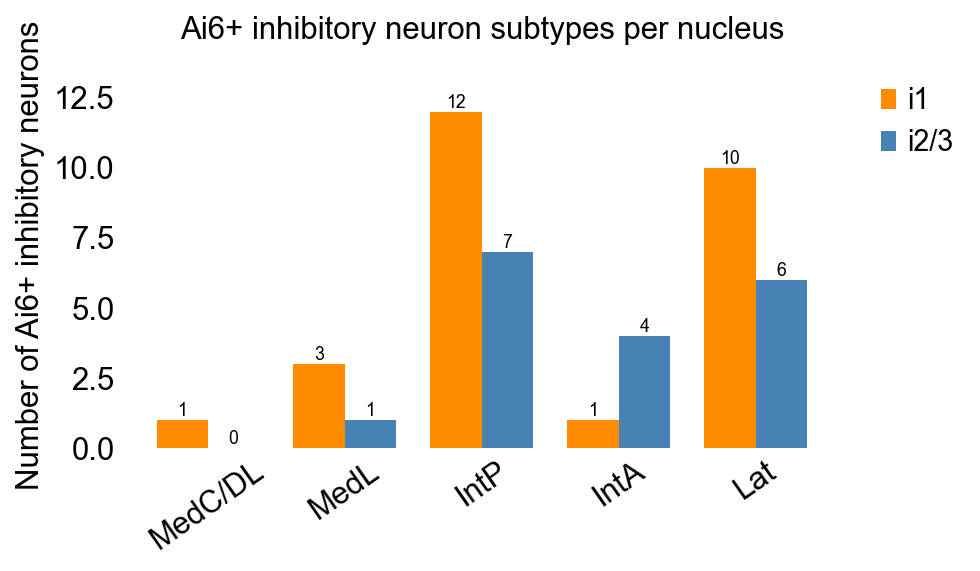

In [ ]:
# --------------------------------------------------
# Plot number of GFP+ inhibitory neurons
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 3.8))

gfp_inhibitory.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    edgecolor="none",
    color={
        "i1": "darkorange",
        "i2/3": "steelblue",
    },
)

ax.set_ylabel("Number of Ai6+ inhibitory neurons")
ax.set_xlabel("")
ax.set_title(
    "Ai6+ inhibitory neuron subtypes per nucleus",
    pad=10,
)

# Add count labels above each bar
n_groups = len(gfp_inhibitory)
n_series = len(gfp_inhibitory.columns)
bar_width = 0.75 / n_series

for j, subtype in enumerate(gfp_inhibitory.columns):
    for i, count in enumerate(gfp_inhibitory[subtype]):
        x = i - 0.75 / 2 + bar_width / 2 + j * bar_width

        ax.text(
            x,
            count,
            str(int(count)),
            ha="center",
            va="bottom",
            fontsize=8,
        )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", rotation=35)
ax.grid(False)
ax.margins(y=0.15)

ax.legend(
    title="",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

inhibitory_subtype,Kit+,Sox14+
nuclei,,
IntP,6,0
Lat,1,2
MedL,2,0
IntA,1,0


inhibitory_subtype,Kit+,Sox14+
nuclei,,
IntP,1.000000,0.000000
Lat,0.333333,0.666667
MedL,1.000000,0.000000
IntA,1.000000,0.000000


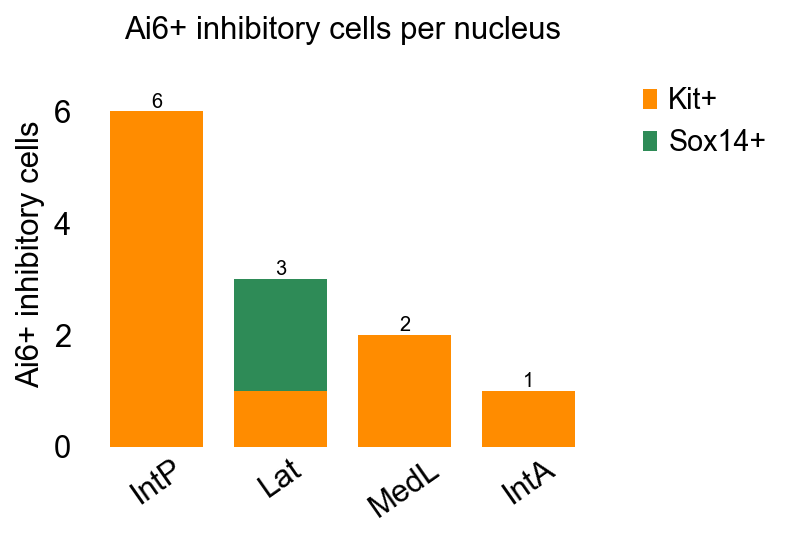

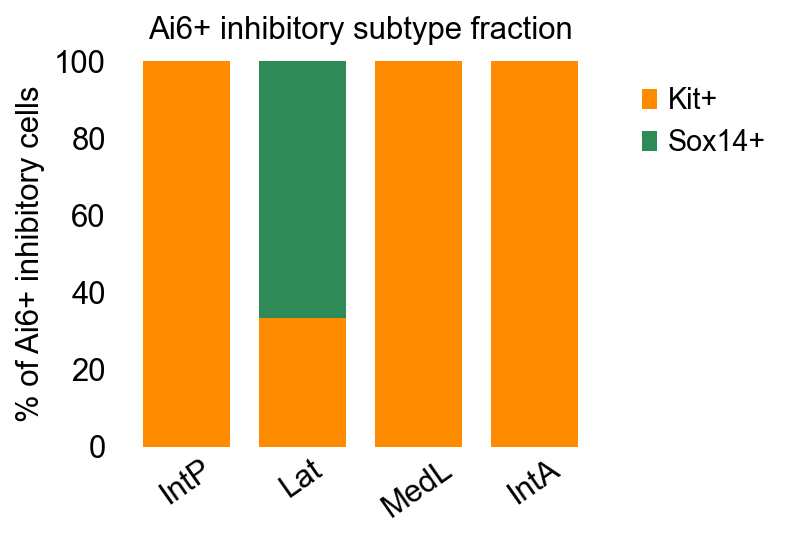

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

def get_expr(adata, gene):
    x = adata[:, gene].X
    return x.toarray().flatten() if hasattr(x, "toarray") else np.asarray(x).flatten()

# -----------------------------
# 1. Call Ai6/GFP+ cells
# -----------------------------
adata_crop_cn_sub.obs["gfp_positive"] = (
    adata_crop_cn_sub.obs["gfp_max_intensity"] > 2000
).astype(int)

# -----------------------------
# 2. Classify excitatory/inhibitory
#    using Slc17a6 / Gad1 ratio
# -----------------------------
gad1 = get_expr(adata_crop_cn_sub, "Gad1")
slc17a6 = get_expr(adata_crop_cn_sub, "Slc17a6")

eps = 1e-6
slc17a6_gad1_ratio = slc17a6 / (gad1 + eps)

adata_crop_cn_sub.obs["slc17a6_gad1_ratio"] = slc17a6_gad1_ratio
adata_crop_cn_sub.obs["marker_class"] = np.nan

adata_crop_cn_sub.obs.loc[
    slc17a6_gad1_ratio > 2,
    "marker_class"
] = "Excitatory"

adata_crop_cn_sub.obs.loc[
    slc17a6_gad1_ratio < 0.5,
    "marker_class"
] = "Inhibitory"

# -----------------------------
# 3. Within inhibitory cells,
#    classify Kit+ vs Sox14+
#    using Sox14 / Kit ratio
# -----------------------------
sox14 = get_expr(adata_crop_cn_sub, "Sox14")
kit = get_expr(adata_crop_cn_sub, "Kit")

sox14_kit_ratio = sox14 / (kit + eps)

adata_crop_cn_sub.obs["sox14_kit_ratio"] = sox14_kit_ratio
adata_crop_cn_sub.obs["inhibitory_subtype"] = np.nan

adata_crop_cn_sub.obs.loc[
    sox14_kit_ratio > 2,
    "inhibitory_subtype"
] = "Sox14+"

adata_crop_cn_sub.obs.loc[
    sox14_kit_ratio < 0.5,
    "inhibitory_subtype"
] = "Kit+"

# -----------------------------
# 4. Keep only:
#    GFP+ cells
#    confident inhibitory cells
#    confident Kit/Sox14 subtype
# -----------------------------
inhib_obs = adata_crop_cn_sub.obs[
    (adata_crop_cn_sub.obs["gfp_positive"] == 1) &
    (adata_crop_cn_sub.obs["marker_class"] == "Inhibitory") &
    (adata_crop_cn_sub.obs["inhibitory_subtype"].notna())
].copy()

nucleus_col = "nuclei"

# -----------------------------
# 5. Count Kit+ / Sox14+ inhibitory Ai6+ cells per nucleus
# -----------------------------
count_df = (
    inhib_obs
    .groupby([nucleus_col, "inhibitory_subtype"], observed=True)
    .size()
    .unstack(fill_value=0)
)

count_df = count_df.loc[
    count_df.sum(axis=1).sort_values(ascending=False).index
]

count_df = count_df[[c for c in ["Kit+", "Sox14+"] if c in count_df.columns]]

fraction_df = count_df.div(count_df.sum(axis=1), axis=0)

display(count_df)
display(fraction_df)

# -----------------------------
# 6. Plot counts
# -----------------------------
fig, ax = plt.subplots(figsize=(5.2, 3.6))

count_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.75,
    edgecolor="none",
    color={
        "Kit+": "darkorange",
        "Sox14+": "seagreen",
    }
)

totals = count_df.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total,
        str(int(total)),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylabel("Ai6+ inhibitory cells")
ax.set_xlabel("")
ax.set_title("Ai6+ inhibitory cells per nucleus", pad=10)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", rotation=35)
ax.grid(False)

ax.legend(
    frameon=False,
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.margins(y=0.15)

plt.tight_layout()
plt.show()

# -----------------------------
# 7. Plot fractions
# -----------------------------
fig, ax = plt.subplots(figsize=(5.2, 3.6))

(fraction_df * 100).plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.75,
    edgecolor="none",
    color={
        "Kit+": "darkorange",
        "Sox14+": "seagreen",
    }
)

ax.set_ylabel("% of Ai6+ inhibitory cells")
ax.set_xlabel("")
ax.set_title("Ai6+ inhibitory subtype fraction", pad=10)
ax.set_ylim(0, 100)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", rotation=35)
ax.grid(False)

ax.legend(
    frameon=False,
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

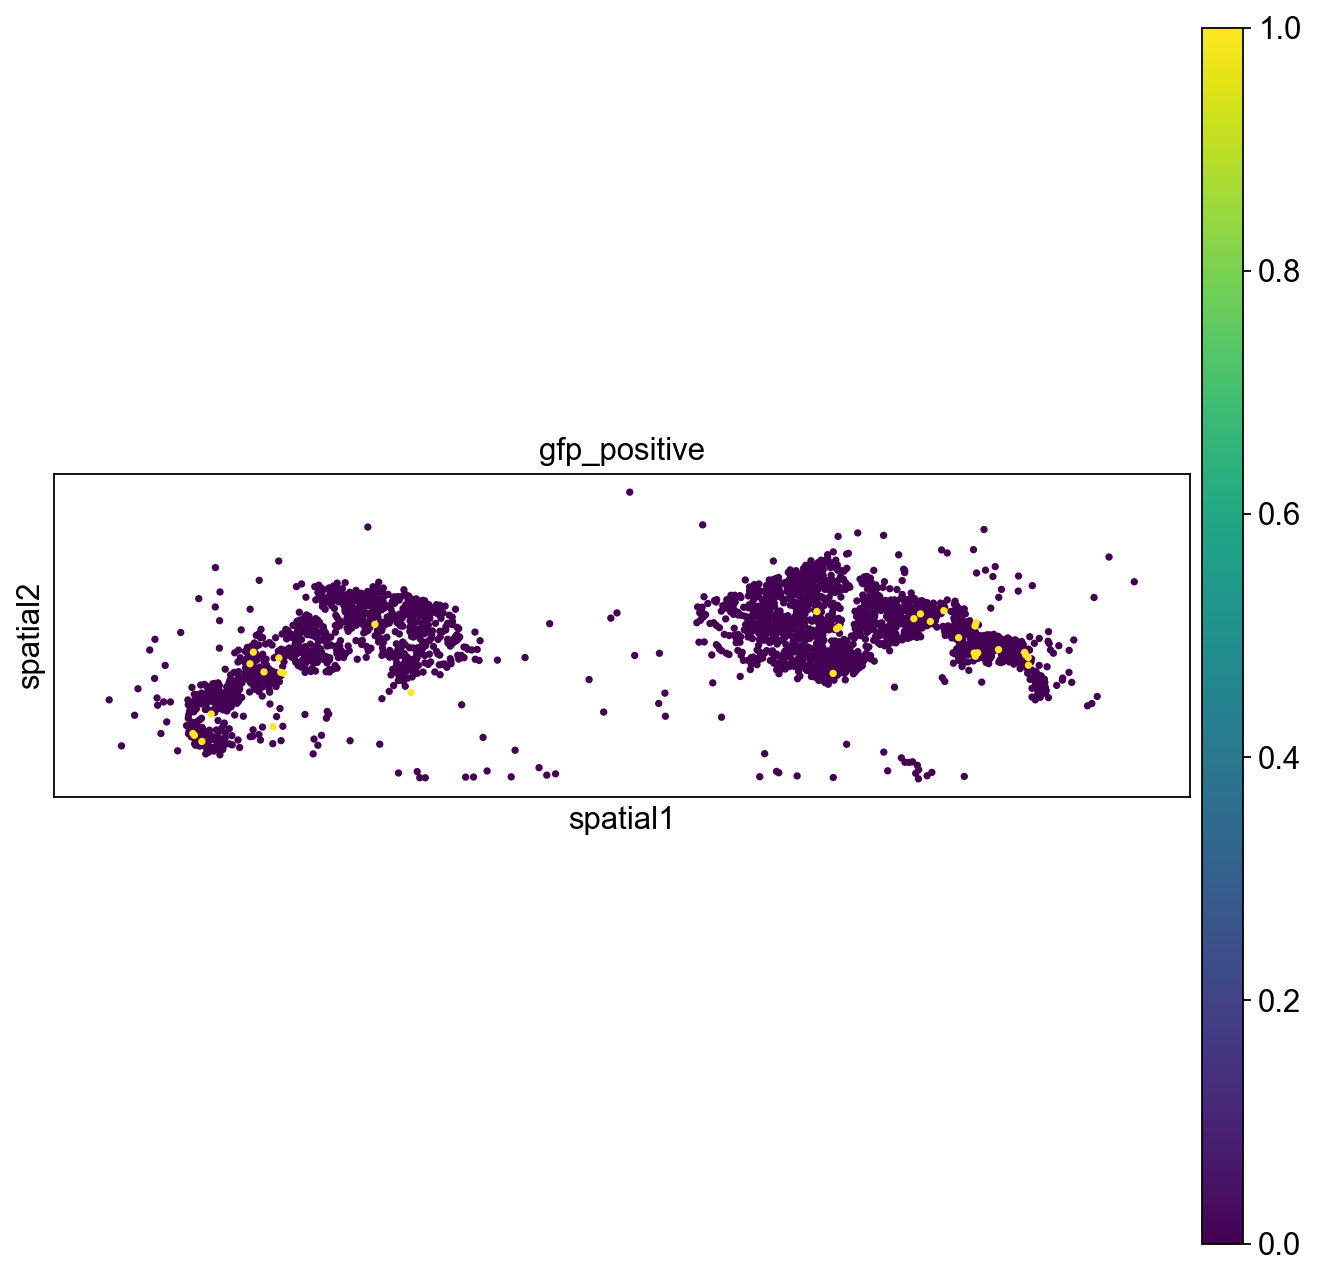

In [ ]:
sc.pl.spatial(adata_crop_cn_sub, color=['gfp_positive'], spot_size=100)


In [ ]:
adata_crop_cn_sub.obs["gfp_positive"]/(adata_crop_cn_sub.obs["gfp_negative"]+adata_crop_cn_sub.obs["gfp_positive"])

cell_number
1001_31    NaN
1001_32    NaN
1002_32    NaN
1003_36    0.5
1006_31    NaN
          ... 
997_17     NaN
997_32     NaN
999_17     NaN
999_32     NaN
999_36     0.5
Length: 2305, dtype: float64

In [ ]:
adata_crop_cn_sub.obs

,cell_number,gfp_mean_intensity,gfp_median_intensity,gfp_std_intensity,gfp_max_intensity,gfp_sum_intensity,gfp_p90_intensity,gfp_p95_intensity,gfp_p99_intensity,gfp_cv_intensity,...,gfp_n_pixels_above_300,gfp_fraction_pixels_above_300,gfp_n_pixels_above_500,gfp_fraction_pixels_above_500,gfp_positive,n_genes_by_counts,total_counts,n_counts,leiden,hybrid_leiden
cell_number,,,,,,,,,,,,,,,,,,,,,
1001_31,1001_31,375.676309,372.5,57.678134,556.0,272741.0,456.0,479.50,498.50,0.153531,...,669,0.921488,7,0.009642,0,3,12,12,1,6
1001_32,1001_32,302.519614,299.0,30.454015,419.0,470418.0,345.0,359.30,384.46,0.100668,...,743,0.477814,0,0.000000,0,11,17,17,1,5
1002_32,1002_32,314.827642,301.0,48.495015,554.0,580857.0,386.6,422.00,476.24,0.154037,...,945,0.512195,2,0.001084,0,7,12,12,1,5
1003_36,1003_36,359.666667,299.0,337.267307,7658.0,1005628.0,432.0,602.00,1673.70,0.937722,...,1368,0.489270,189,0.067597,1,11,36,36,1,2
1006_31,1006_31,304.210604,301.0,55.362587,499.0,413118.0,380.0,401.00,433.43,0.181988,...,685,0.504418,0,0.000000,0,8,22,22,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997_17,997_17,308.404873,305.0,42.905261,429.0,329068.0,366.0,381.00,404.34,0.139120,...,572,0.536082,0,0.000000,0,6,12,12,1,0
997_32,997_32,415.319961,401.0,97.222715,673.0,859297.0,555.2,577.00,619.96,0.234091,...,1813,0.876269,500,0.241663,0,8,32,32,1,5
999_17,999_17,282.340535,279.0,31.636908,429.0,771072.0,324.0,340.00,372.70,0.112052,...,692,0.253387,0,0.000000,0,8,16,16,1,0


In [ ]:
# Based on manual classification and correlation with cells from manual classfication (Supp Table 2)
medcdl = [0,1]
medl = [6,5]
lat = [5,6]
int = [5,11]

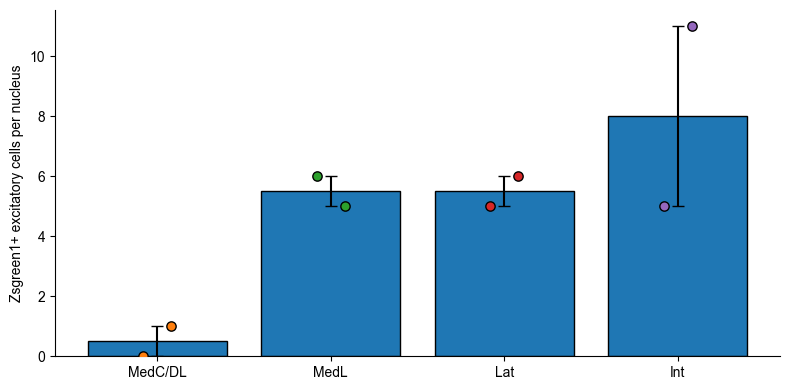

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"
data = {
    "MedC/DL": [0, 1],
    "MedL": [6, 5],
    "Lat": [5, 6],
    "Int": [5, 11],
}

labels = list(data.keys())
values = [np.asarray(data[label], dtype=float) for label in labels]

means = np.array([x.mean() for x in values])
sems = np.array([
    x.std(ddof=1) / np.sqrt(len(x))
    if len(x) > 1 else 0
    for x in values
])

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 4))

# Mean bars with SEM
ax.bar(
    x,
    means,
    yerr=sems,
    capsize=4,
    edgecolor="black",
    linewidth=1,
)

# Individual replicate values
offsets = np.array([-0.08, 0.08])

for i, vals in enumerate(values):
    ax.scatter(
        x[i] + offsets[:len(vals)],
        vals,
        s=45,
        edgecolor="black",
        zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Zsgreen1+ excitatory cells per nucleus")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("nuclei_counts.svg", bbox_inches="tight")
plt.savefig("nuclei_counts.pdf", bbox_inches="tight")
plt.show()